# Week-29

,FoodWeb,Scenario,Required negative links,Total available negative pool,Role-constrained pool,Selected Role+Mass,Selected Role+No mass,Selected No role+Mass,Selected No role+No mass
0,PC1P2,Needs random top-up,212,314,120,95,25,31,61
1,Skipwith Pond,Needs random top-up,708,768,65,9,56,397,246


### Skipwith Pond
- Scenario: **Needs random top-up**
- Required negative links: **708**
- Role-constrained pool: **65**
- Total available negative pool: **768**
- Empirical links: **354**, nodes: **34**

,FoodWeb,Basal resource,Primary consumer,Apex predator,Unknown,Computed Role+Mass pool,Computed Role+No mass pool,Computed No role+Mass pool,Computed No role+No mass pool
0,Skipwith Pond,1,32,1,0,9,56,444,259


,NodeID,Taxon,Role,Mass
0,1,Acanthocyclops vernalis,Primary consumer,0.00220
1,2,Aeshna juncea,Primary consumer,2.70280
2,3,Agabus bipustulatus,Primary consumer,0.61200
3,4,Agabus sturmii,Primary consumer,0.28220
4,5,Arctocorisa germari,Primary consumer,0.21800
5,6,Argyroneta aquatica,Primary consumer,0.27220
6,7,Callicorixa praeusta,Primary consumer,0.19890
7,8,Chironomidae indet.,Primary consumer,0.03820
8,9,Chironomus dorsalis,Primary consumer,0.14720
9,10,Chydorus latus,Primary consumer,0.00010


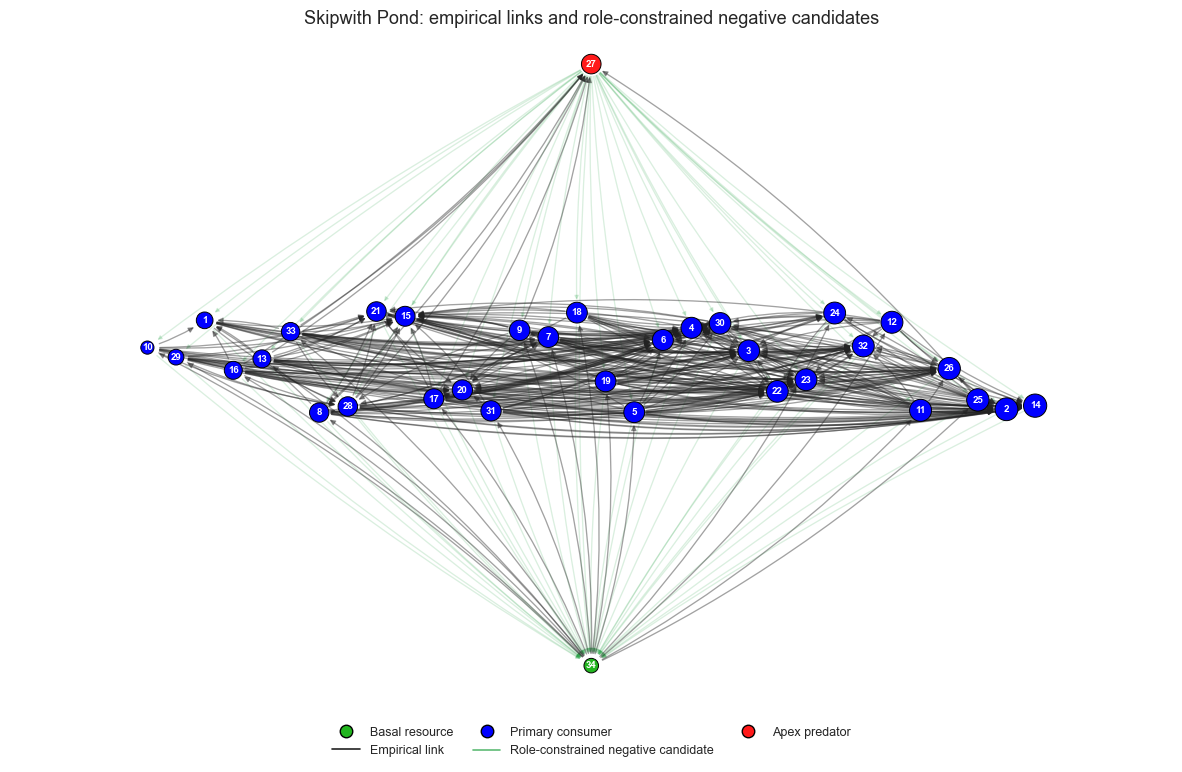

### PC1P2
- Scenario: **Needs random top-up**
- Required negative links: **212**
- Role-constrained pool: **120**
- Total available negative pool: **314**
- Empirical links: **106**, nodes: **21**

,FoodWeb,Basal resource,Primary consumer,Apex predator,Unknown,Computed Role+Mass pool,Computed Role+No mass pool,Computed No role+Mass pool,Computed No role+No mass pool
0,PC1P2,6,15,0,0,95,25,87,107


,NodeID,Taxon,Role,Mass
0,1,Ampithoidae,Primary consumer,0.007600
1,2,Anemonia sargassensis,Primary consumer,0.010000
2,3,Caprella sp.,Primary consumer,0.000400
3,4,Caulerpa webbiana,Basal resource,0.000228
4,5,Cladophora prolifera,Basal resource,0.000228
5,6,Copepoda,Primary consumer,0.001000
6,7,Coryphoblennius galerita,Primary consumer,1.050000
7,8,Gammaridae,Primary consumer,0.001300
8,9,Insecta,Primary consumer,0.000700
9,10,Isopoda,Primary consumer,0.010000


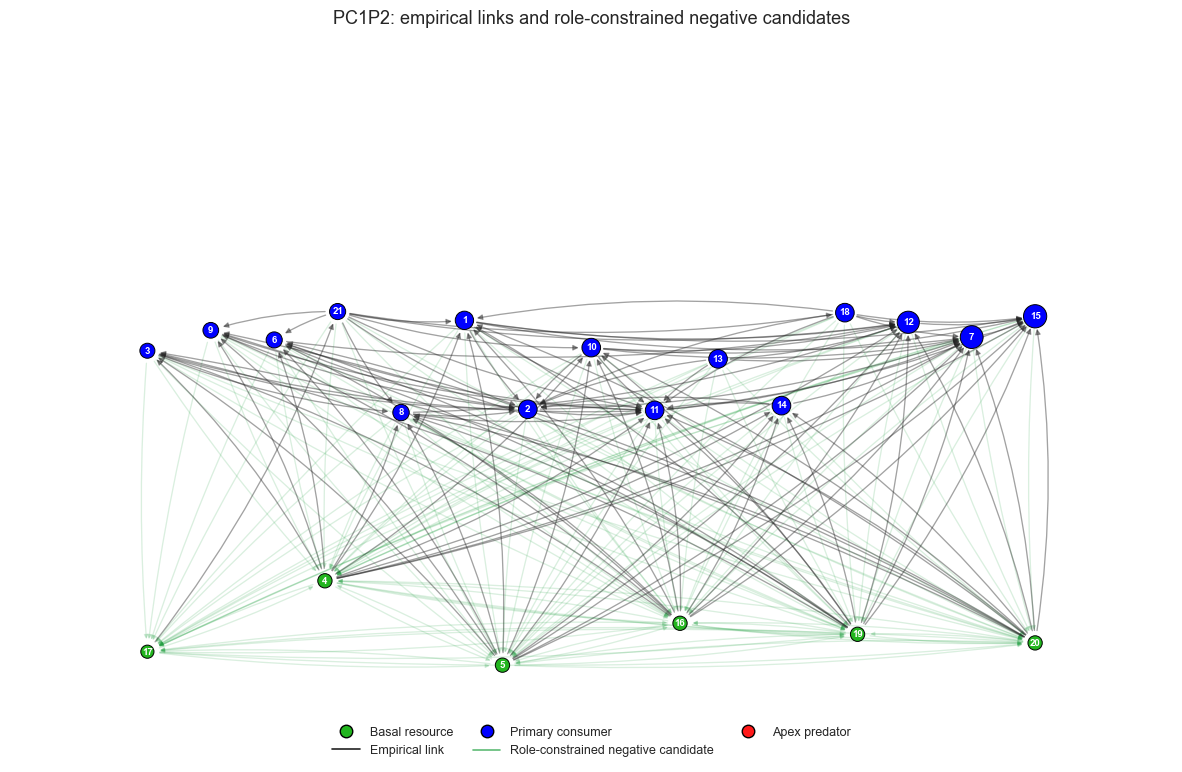

In [11]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from scipy.io import loadmat
from scipy import sparse
from IPython.display import display, Markdown

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

MAT_DIR = REPO_ROOT / "src/matlab/data/foodwebs_mat"

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_massdiag_trainmetrics_checkconnfalse_Apocrita"
)

LOG_DIR = RESULT_DIR / "terminal_logs"

TARGET_FOODWEBS = [
    "Skipwith Pond",
    "PC1P2",
]

SAVE_FIGURES = False
FIG_DIR = RESULT_DIR / "figures/negative_sampling_role_pool"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Role codes are the same as sample_neg_dir_neg.m:
# consumer = 1, resource = 2, consumer-resource = 3
ROLE_CODE = {
    "consumer": 1,
    "resource": 2,
    "consumer-resource": 3,
    "consumer resource": 3,
    "consumer_resource": 3,
}

ROLE_LABEL = {
    1: "Apex predator",
    2: "Basal resource",
    3: "Primary consumer",
    0: "Unknown",
}

ROLE_COLOR = {
    1: "#FF1A1A",  # Apex predator - red
    2: "#22B51F",  # Basal resource - green
    3: "#0000FF",  # Primary consumer - blue
    0: "#111111",  # Unknown - black
}

# Five allowed role-constrained negative candidate pairs in WLNM_dir_neg.
ALLOWED_ROLE_PAIRS = {
    (1, 1),  # consumer -> consumer
    (2, 2),  # resource -> resource
    (1, 2),  # consumer -> resource
    (1, 3),  # consumer -> consumer-resource
    (3, 2),  # consumer-resource -> resource
}

# -----------------------------
# Parse negative-sampling log info
# -----------------------------
negpool_pattern = re.compile(
    r"\[NegPool\].*?"
    r"role_pool=(?P<role_pool>\d+)\s+"
    r"full_pool=(?P<full_pool>\d+)\s+"
    r"need_total=(?P<need_total>\d+)"
)

mass_pattern = re.compile(
    r"\[NegMassPref\].*?"
    r"role_mass=(?P<role_mass>\d+)\s+"
    r"role_other=(?P<role_other>\d+)\s+"
    r"nonrole_mass=(?P<nonrole_mass>\d+)\s+"
    r"nonrole_other=(?P<nonrole_other>\d+)"
)

def parse_negative_sampling_logs(log_dir: Path) -> pd.DataFrame:
    rows = []

    for log_file in sorted(log_dir.glob("*_terminal_log.txt")):
        foodweb = (
            log_file.name
            .replace("_wlnm_dir_neg_terminal_log.txt", "")
            .removesuffix("_tax_mass")
        )

        negpool_matches = []
        mass_matches = []

        for line in log_file.read_text(errors="ignore").splitlines():
            negpool_match = negpool_pattern.search(line)
            if negpool_match:
                negpool_matches.append(
                    tuple(int(v) for v in negpool_match.groupdict().values())
                )

            mass_match = mass_pattern.search(line)
            if mass_match:
                mass_matches.append(
                    tuple(int(v) for v in mass_match.groupdict().values())
                )

        if not negpool_matches or not mass_matches:
            continue

        role_pool, full_pool, need_total = sorted(set(negpool_matches))[0]
        role_mass, role_other, nonrole_mass, nonrole_other = sorted(set(mass_matches))[0]

        if nonrole_other > 0:
            scenario = "Needs random top-up"
        elif nonrole_mass > 0:
            scenario = "Completed by mass preference"
        else:
            scenario = "Role constraints sufficient"

        rows.append({
            "FoodWeb": foodweb,
            "Scenario": scenario,
            "Required negative links": need_total,
            "Total available negative pool": full_pool,
            "Role-constrained pool": role_pool,
            "Selected Role+Mass": role_mass,
            "Selected Role+No mass": role_other,
            "Selected No role+Mass": nonrole_mass,
            "Selected No role+No mass": nonrole_other,
        })

    return pd.DataFrame(rows)

negative_sampling_df = parse_negative_sampling_logs(LOG_DIR)

display(
    negative_sampling_df[
        negative_sampling_df["FoodWeb"].isin(TARGET_FOODWEBS)
    ].reset_index(drop=True)
)

# -----------------------------
# MAT helpers
# -----------------------------
def matlab_string_array_to_list(x):
    arr = np.asarray(x).squeeze()

    if arr.ndim == 0:
        return [str(arr.item()).strip()]

    out = []
    for item in arr.ravel():
        if isinstance(item, np.ndarray):
            item = np.asarray(item).squeeze()
            if item.ndim == 0:
                out.append(str(item.item()).strip())
            else:
                out.append("".join(item.astype(str).ravel()).strip())
        else:
            out.append(str(item).strip())

    return out

def load_foodweb_mat(foodweb_name: str):
    mat_path = MAT_DIR / f"{foodweb_name}_tax_mass.mat"

    if not mat_path.exists():
        raise FileNotFoundError(f"MAT file not found: {mat_path}")

    data = loadmat(
        mat_path,
        squeeze_me=True,
        struct_as_record=False,
        spmatrix=True,
    )

    required = ["net", "taxonomy", "mass", "role"]
    missing = [k for k in required if k not in data]

    if missing:
        raise KeyError(f"Missing fields in {mat_path.name}: {missing}")

    net = data["net"]
    if sparse.issparse(net):
        net = net.tocsr()
    else:
        net = sparse.csr_matrix((np.asarray(net) > 0).astype(np.int8))

    n = net.shape[0]

    taxonomy = matlab_string_array_to_list(data["taxonomy"])
    role = matlab_string_array_to_list(data["role"])

    if len(taxonomy) < n:
        taxonomy = taxonomy + [f"node_{i+1}" for i in range(len(taxonomy), n)]

    if len(role) < n:
        role = role + ["unknown"] * (n - len(role))

    mass = np.asarray(data["mass"]).astype(float).reshape(-1)
    if mass.size < n:
        mass = np.pad(mass, (0, n - mass.size), constant_values=np.nan)

    return {
        "path": mat_path,
        "net": net,
        "taxonomy": taxonomy[:n],
        "role": role[:n],
        "mass": mass[:n],
    }

def encode_role(role_value: str) -> int:
    key = str(role_value).strip().lower()
    return ROLE_CODE.get(key, 0)

def compute_negative_candidate_categories(net, role_codes, mass):
    n = net.shape[0]
    net_bool = net.astype(bool).tocsr()

    role_candidates = []
    category_counts = {
        "Role+Mass": 0,
        "Role+No mass": 0,
        "No role+Mass": 0,
        "No role+No mass": 0,
    }

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            if net_bool[i, j]:
                continue

            is_role = (role_codes[i], role_codes[j]) in ALLOWED_ROLE_PAIRS

            valid_mass = (
                np.isfinite(mass[i])
                and np.isfinite(mass[j])
                and mass[i] > 0
                and mass[j] > 0
            )
            is_mass = valid_mass and (mass[j] / mass[i] < 1)

            if is_role and is_mass:
                category_counts["Role+Mass"] += 1
                role_candidates.append((i, j))
            elif is_role and not is_mass:
                category_counts["Role+No mass"] += 1
                role_candidates.append((i, j))
            elif (not is_role) and is_mass:
                category_counts["No role+Mass"] += 1
            else:
                category_counts["No role+No mass"] += 1

    return {
        "role_candidates": role_candidates,
        "category_counts": category_counts,
    }

def scaled_node_sizes(mass, min_size=90, max_size=280):
    mass = np.asarray(mass, dtype=float)
    valid = np.isfinite(mass) & (mass > 0)

    sizes = np.full(mass.shape, min_size + 20.0, dtype=float)

    if valid.sum() >= 2:
        log_mass = np.log10(mass[valid])
        lo, hi = np.nanmin(log_mass), np.nanmax(log_mass)

        if hi > lo:
            sizes[valid] = min_size + (log_mass - lo) / (hi - lo) * (max_size - min_size)
        else:
            sizes[valid] = (min_size + max_size) / 2

    return sizes

def role_layered_layout(role_codes, mass):
    """
    Visual role-layer layout.

    Basal resources are placed at the bottom.
    Primary consumers are placed in the middle.
    Apex predators are placed at the top.

    This is a role-based visual layout, not a calculated trophic-height layout.
    """
    n = len(role_codes)

    y_by_role = {
        2: 0.0,  # Basal resource
        3: 1.0,  # Primary consumer
        1: 2.0,  # Apex predator
        0: 3.0,  # Unknown
    }

    xy = np.zeros((n, 2), dtype=float)

    mass = np.asarray(mass, dtype=float)
    log_mass = np.full(n, np.nan)
    valid_mass = np.isfinite(mass) & (mass > 0)
    log_mass[valid_mass] = np.log10(mass[valid_mass])

    for role_code in [2, 3, 1, 0]:
        idx = np.where(role_codes == role_code)[0]

        if len(idx) == 0:
            continue

        valid_idx = idx[np.isfinite(log_mass[idx])]
        invalid_idx = idx[~np.isfinite(log_mass[idx])]

        if len(valid_idx):
            valid_idx = valid_idx[np.argsort(log_mass[valid_idx])]

        ordered_idx = np.concatenate([valid_idx, invalid_idx])

        if len(ordered_idx) == 1:
            x_values = np.array([0.5])
        else:
            x_values = np.linspace(0.08, 0.92, len(ordered_idx))

        y_base = y_by_role.get(role_code, 3.0)

        for x, node_idx in zip(x_values, ordered_idx):
            jitter = 0.2 * np.sin((node_idx + 1) * 2.17)
            xy[node_idx, 0] = float(x)
            xy[node_idx, 1] = float(y_base + jitter)

    return xy

def draw_arrow(ax, xy, i, j, color, linewidth, mutation_scale, alpha, rad, zorder):
    x1, y1 = xy[i]
    x2, y2 = xy[j]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=linewidth,
        color=color,
        alpha=alpha,
        shrinkA=9,
        shrinkB=9,
        connectionstyle=f"arc3,rad={rad}",
        zorder=zorder,
    )
    ax.add_patch(arrow)

def draw_foodweb_matplotlib(foodweb_name: str):
    fw = load_foodweb_mat(foodweb_name)

    net = fw["net"]
    taxonomy = fw["taxonomy"]
    roles = fw["role"]
    mass = fw["mass"]
    n = net.shape[0]

    role_codes = np.array([encode_role(r) for r in roles], dtype=int)

    neg_info = negative_sampling_df[
        negative_sampling_df["FoodWeb"].eq(foodweb_name)
    ]

    log_row = None if neg_info.empty else neg_info.iloc[0].to_dict()

    candidates = compute_negative_candidate_categories(net, role_codes, mass)
    role_candidates = candidates["role_candidates"]
    category_counts = candidates["category_counts"]

    src, tgt = net.nonzero()
    empirical_edges = [(int(i), int(j)) for i, j in zip(src, tgt) if i != j]

    role_counts = pd.Series(role_codes).map(ROLE_LABEL).value_counts().to_dict()

    if log_row is not None:
        title_md = (
            f"### {foodweb_name}\n"
            f"- Scenario: **{log_row['Scenario']}**\n"
            f"- Required negative links: **{log_row['Required negative links']}**\n"
            f"- Role-constrained pool: **{log_row['Role-constrained pool']}**\n"
            f"- Total available negative pool: **{log_row['Total available negative pool']}**\n"
            f"- Empirical links: **{len(empirical_edges)}**, nodes: **{n}**"
        )
    else:
        title_md = (
            f"### {foodweb_name}\n"
            f"- Empirical links: **{len(empirical_edges)}**, nodes: **{n}**"
        )

    display(Markdown(title_md))

    display(pd.DataFrame([{
        "FoodWeb": foodweb_name,
        "Basal resource": role_counts.get("Basal resource", 0),
        "Primary consumer": role_counts.get("Primary consumer", 0),
        "Apex predator": role_counts.get("Apex predator", 0),
        "Unknown": role_counts.get("Unknown", 0),
        "Computed Role+Mass pool": category_counts["Role+Mass"],
        "Computed Role+No mass pool": category_counts["Role+No mass"],
        "Computed No role+Mass pool": category_counts["No role+Mass"],
        "Computed No role+No mass pool": category_counts["No role+No mass"],
    }]))

    xy = role_layered_layout(role_codes, mass)
    node_sizes = scaled_node_sizes(mass)
    node_colors = [ROLE_COLOR.get(int(role_codes[i]), ROLE_COLOR[0]) for i in range(n)]

    fig, ax = plt.subplots(figsize=(15, 10))

    # Role-constrained negative candidates.
    for i, j in role_candidates:
        draw_arrow(
            ax=ax,
            xy=xy,
            i=i,
            j=j,
            color="#1B9E3C",
            linewidth=0.95,
            mutation_scale=6,
            alpha=0.16,
            rad=0.04,
            zorder=1,
        )

    # Empirical links.
    for i, j in empirical_edges:
        draw_arrow(
            ax=ax,
            xy=xy,
            i=i,
            j=j,
            color="#222222",
            linewidth=0.95,
            mutation_scale=8,
            alpha=0.42,
            rad=0.08,
            zorder=2,
        )

    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=node_sizes,
        c=node_colors,
        edgecolors="black",
        linewidths=0.7,
        zorder=3,
    )

    for i, (x, y) in enumerate(xy):
        ax.text(
            x,
            y,
            str(i + 1),
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            zorder=4,
        )

    lookup_df = pd.DataFrame({
        "NodeID": np.arange(1, n + 1),
        "Taxon": taxonomy,
        "Role": [ROLE_LABEL.get(int(c), "Unknown") for c in role_codes],
        "Mass": mass,
    })
    display(lookup_df)

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markersize=9,
            markerfacecolor=ROLE_COLOR[2],
            markeredgecolor="black",
            label="Basal resource",
        ),
        Line2D([0], [0], color="#222222", lw=1.2, label="Empirical link"),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markersize=9,
            markerfacecolor=ROLE_COLOR[3],
            markeredgecolor="black",
            label="Primary consumer",
        ),
        Line2D(
            [0],
            [0],
            color="#1B9E3C",
            lw=1.2,
            alpha=0.7,
            label="Role-constrained negative candidate",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markersize=9,
            markerfacecolor=ROLE_COLOR[1],
            markeredgecolor="black",
            label="Apex predator",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.045),  # outside the axes frame
        ncol=3,
        frameon=False,
        fontsize=9,
        handlelength=2.2,
        columnspacing=1.6,
    )

    # Leave extra space below the axes for the external legend.
    fig.subplots_adjust(bottom=0.24)

    ax.set_title(
        f"{foodweb_name}: empirical links and role-constrained negative candidates",
        fontsize=13,
        pad=16,
    )

    top_y = 3.25 if np.any(role_codes == 0) else 2.25

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.28, top_y)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    # plt.tight_layout()

    if SAVE_FIGURES:
        out_path = FIG_DIR / f"{foodweb_name.replace(' ', '_')}_role_negative_pool_matplotlib.png"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] Saved figure: {out_path}")

    plt.show()


for foodweb_name in TARGET_FOODWEBS:
    draw_foodweb_matplotlib(foodweb_name)

Valid links loaded: 200,510
Food webs represented: 290


InteractionType,ValidLinks
str,u32
"""predacious""",158691
"""herbivorous""",38075
"""parasitoid""",1633
"""parasitic""",1026
"""bacterivorous""",1003
"""fungivorous""",82


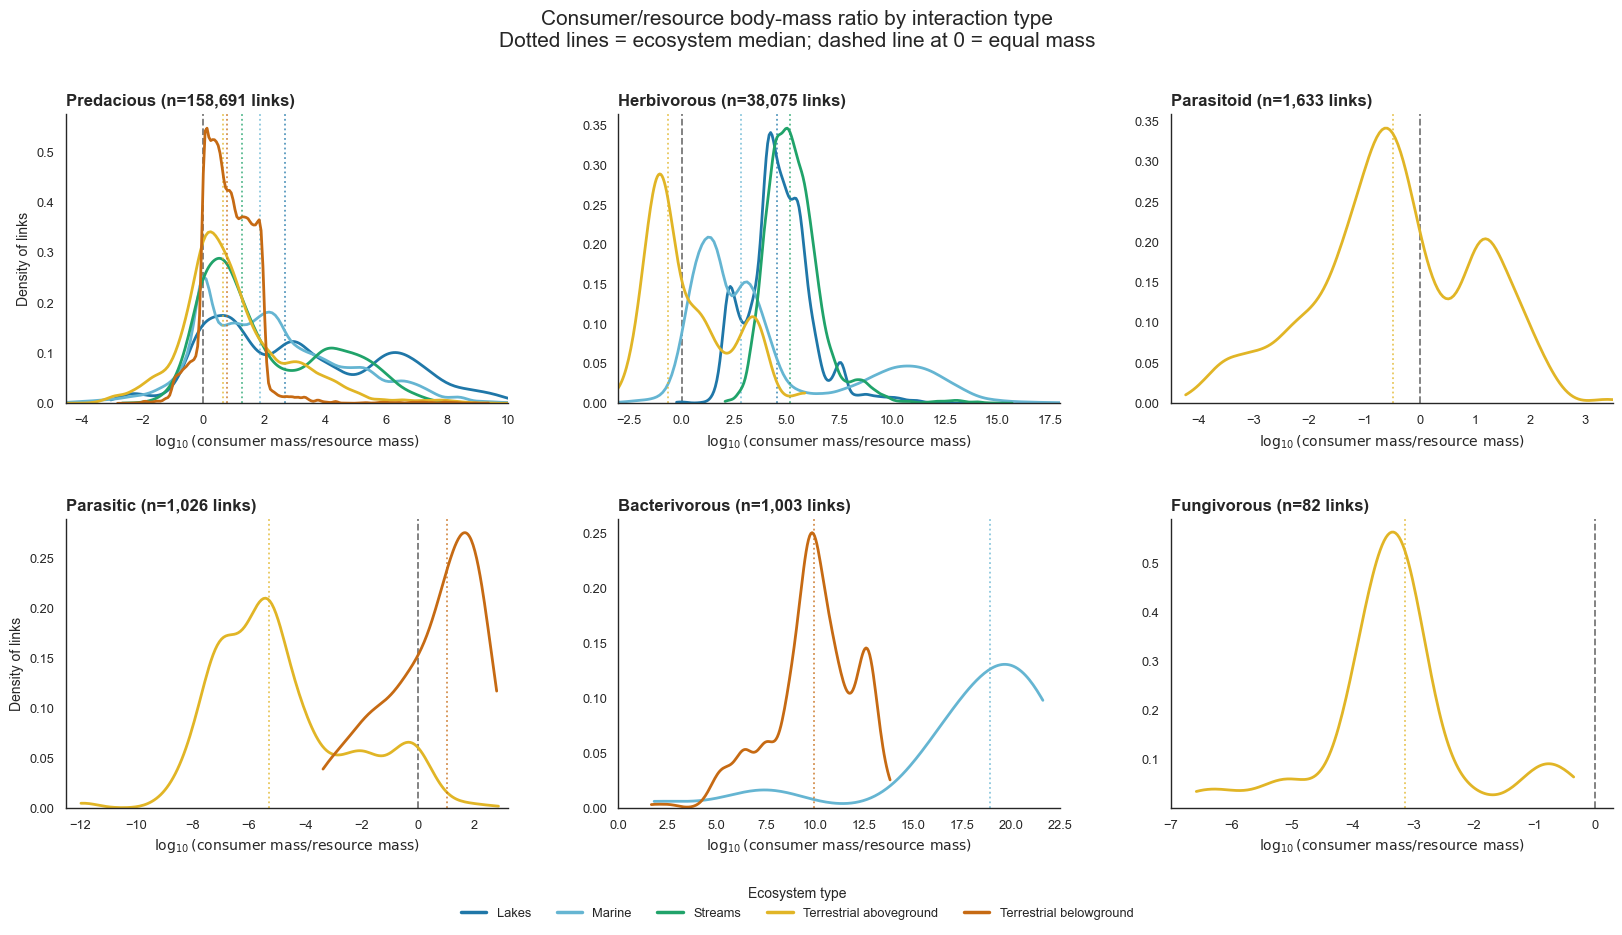

In [12]:
from pathlib import Path

import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Configuration
# ============================================================
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RAW_CSV = (
    REPO_ROOT
    / "data/raw/283_3_Dataset"
    / "283_2_FoodWebDataBase_2018_12_10.csv"
)

interaction_order = [
    "predacious",
    "herbivorous",
    "parasitoid",
    "parasitic",
    "bacterivorous",
    "fungivorous",
]

interaction_labels = {
    "predacious": "Predacious",
    "herbivorous": "Herbivorous",
    "parasitoid": "Parasitoid",
    "parasitic": "Parasitic",
    "bacterivorous": "Bacterivorous",
    "fungivorous": "Fungivorous",
}

ecosystem_order = [
    "lakes",
    "marine",
    "streams",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "marine": "Marine",
    "streams": "Streams",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

# Similar to the colours visible in Lachlan's figure
ecosystem_palette = {
    "lakes": "#1F77A8",
    "marine": "#65B5D2",
    "streams": "#20A36A",
    "terrestrial aboveground": "#E1B526",
    "terrestrial belowground": "#C66A13",
}

# Limits chosen to make the panels directly comparable with the screenshot.
# Remove ax.set_xlim(...) below to display the complete observed range.
x_limits = {
    "predacious": (-4.5, 10.0),
    "herbivorous": (-3.0, 18.0),
    "parasitoid": (-4.5, 3.5),
    "parasitic": (-12.5, 3.2),
    "bacterivorous": (0.0, 22.5),
    "fungivorous": (-7.0, 0.3),
}

# KDE smoothing. Increase for smoother curves; decrease for more detail.
BW_ADJUST = 0.85
MIN_LINKS_FOR_KDE = 10

# ============================================================
# Load and clean with Polars
# ============================================================
links = (
    pl.scan_csv(
        RAW_CSV,
        infer_schema_length=10_000,
        null_values=["NA"],
    )
    .select(
        pl.col("interaction.type").alias("InteractionType"),
        pl.col("ecosystem.type").alias("Ecosystem"),
        pl.col("con.mass.mean.g.")
        .cast(pl.Float64, strict=False)
        .alias("ConsumerMass"),
        pl.col("res.mass.mean.g.")
        .cast(pl.Float64, strict=False)
        .alias("ResourceMass"),
        pl.col("foodweb.name").alias("FoodWeb"),
    )
    .filter(
        pl.col("InteractionType").is_in(interaction_order)
        & pl.col("Ecosystem").is_in(ecosystem_order)
        & pl.col("ConsumerMass").is_finite()
        & pl.col("ResourceMass").is_finite()
        & (pl.col("ConsumerMass") > 0)
        & (pl.col("ResourceMass") > 0)
    )
    .with_columns(
        (pl.col("ConsumerMass") / pl.col("ResourceMass"))
        .alias("MassRatio")
    )
    .with_columns(
        pl.col("MassRatio")
        .log10()
        .alias("Log10MassRatio")
    )
    .collect()
)

print(f"Valid links loaded: {links.height:,}")
print(f"Food webs represented: {links['FoodWeb'].n_unique()}")

# Validate counts against Lachlan's figure
interaction_counts = (
    links
    .group_by("InteractionType")
    .agg(pl.len().alias("ValidLinks"))
    .with_columns(
        pl.col("InteractionType")
        .replace_strict(
            {name: position for position, name in enumerate(interaction_order)}
        )
        .alias("Order")
    )
    .sort("Order")
    .drop("Order")
)

display(interaction_counts)

# ============================================================
# Plot
# ============================================================
sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.05,
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(17, 9.5),
    sharex=False,
    sharey=False,
)

axes = np.asarray(axes).reshape(-1)

for panel_index, (ax, interaction_type) in enumerate(
    zip(axes, interaction_order)
):
    interaction_df = links.filter(
        pl.col("InteractionType") == interaction_type
    )

    n_links = interaction_df.height

    for ecosystem in ecosystem_order:
        values = (
            interaction_df
            .filter(pl.col("Ecosystem") == ecosystem)
            .get_column("Log10MassRatio")
            .to_numpy()
        )

        values = values[np.isfinite(values)]

        if (
            len(values) < MIN_LINKS_FOR_KDE
            or np.unique(values).size < 2
        ):
            continue

        color = ecosystem_palette[ecosystem]

        # Each ecosystem distribution is independently normalized.
        sns.kdeplot(
            x=values,
            ax=ax,
            color=color,
            linewidth=2.0,
            bw_adjust=BW_ADJUST,
            cut=0,
            warn_singular=False,
        )

        # Ecosystem-specific median
        ax.axvline(
            np.median(values),
            color=color,
            linestyle=":",
            linewidth=1.3,
            alpha=0.75,
        )

    # log10 ratio = 0 means equal consumer and resource mass
    ax.axvline(
        0,
        color="dimgray",
        linestyle="--",
        linewidth=1.3,
        alpha=0.9,
        zorder=0,
    )

    ax.set_title(
        f"{interaction_labels[interaction_type]} "
        f"(n={n_links:,} links)",
        loc="left",
        fontsize=12,
        fontweight="bold",
    )

    ax.set_xlabel(
        r"$\log_{10}(\mathrm{consumer\ mass}/\mathrm{resource\ mass})$"
    )

    if panel_index % 3 == 0:
        ax.set_ylabel("Density of links")
    else:
        ax.set_ylabel("")

    ax.set_xlim(x_limits[interaction_type])
    ax.grid(False)
    sns.despine(ax=ax)

# ============================================================
# Global legend
# ============================================================
legend_handles = [
    Line2D(
        [0],
        [0],
        color=ecosystem_palette[ecosystem],
        linewidth=2.5,
        label=ecosystem_labels[ecosystem],
    )
    for ecosystem in ecosystem_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
    frameon=False,
    title="Ecosystem type",
)

fig.suptitle(
    "Consumer/resource body-mass ratio by interaction type\n"
    "Dotted lines = ecosystem median; dashed line at 0 = equal mass",
    fontsize=15,
    y=0.98,
)

fig.subplots_adjust(
    top=0.87,
    bottom=0.14,
    left=0.07,
    right=0.98,
    hspace=0.40,
    wspace=0.25,
)

plt.show()

Valid non-parasitic links: 199,601
Food webs represented: 290


LinkEcosystem,ValidLinks
str,u32
"""lakes""",9328
"""marine""",65127
"""streams""",17506
"""terrestrial aboveground""",19906
"""terrestrial belowground""",87734


WebEcosystem,FoodWebs,MedianValidLinks,MedianOfWebMedians
str,u32,f64,f64
"""lakes""",56,136.5,4.116339
"""marine""",135,147.0,1.642065
"""streams""",28,114.0,4.693478
"""terrestrial aboveground""",21,810.0,1.018411
"""terrestrial belowground""",52,1704.0,0.798716


Food webs retained: 290


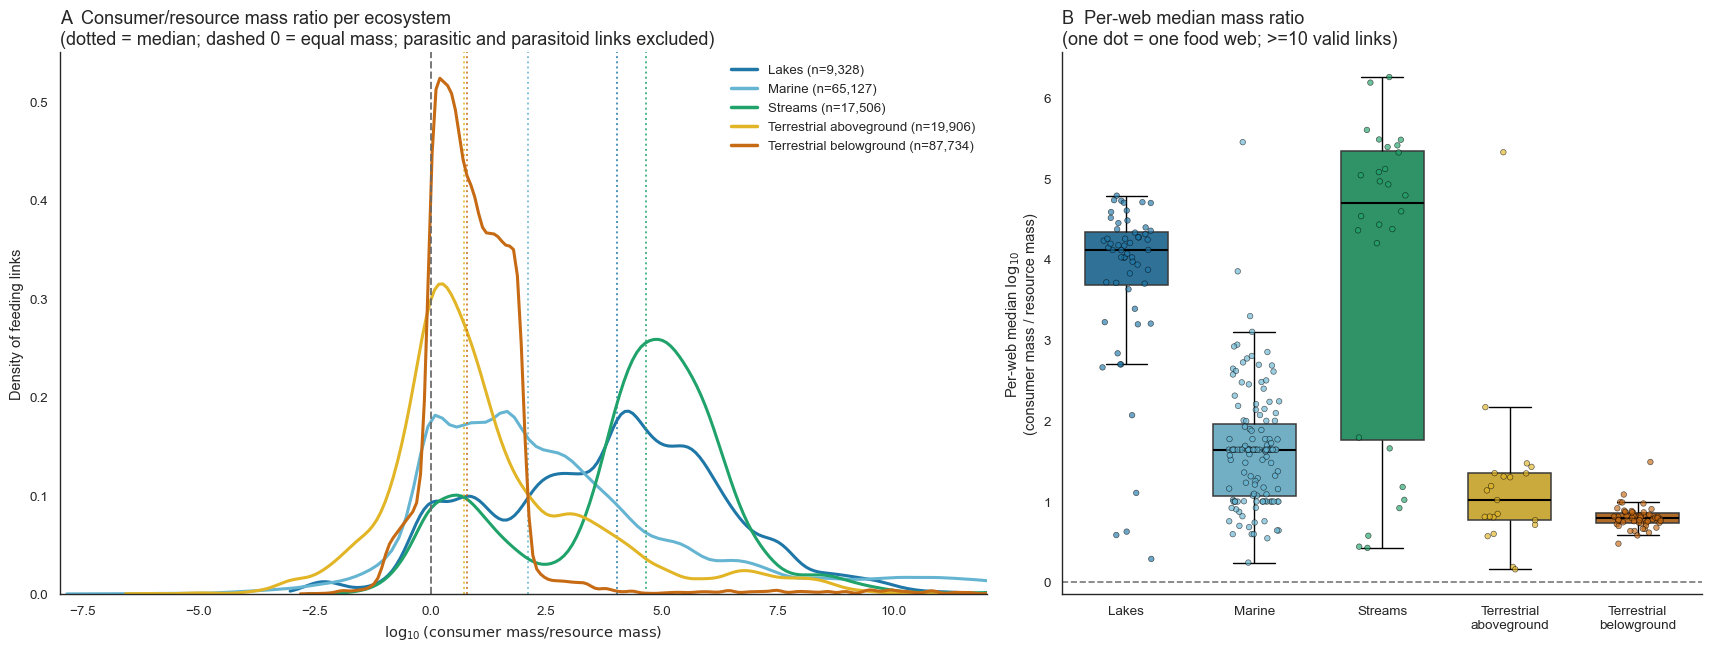

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Configuration
# ============================================================
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RAW_CSV = (
    REPO_ROOT
    / "data/raw/283_3_Dataset"
    / "283_2_FoodWebDataBase_2018_12_10.csv"
)

ECOSYSTEM_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

EXCLUDED_INTERACTIONS = [
    "parasitic",
    "parasitoid",
]

MIN_VALID_LINKS_PER_WEB = 10
BW_ADJUST = 0.85

ecosystem_order = [
    "lakes",
    "marine",
    "streams",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "marine": "Marine",
    "streams": "Streams",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

ecosystem_palette = {
    "lakes": "#1F77A8",
    "marine": "#65B5D2",
    "streams": "#20A36A",
    "terrestrial aboveground": "#E1B526",
    "terrestrial belowground": "#C66A13",
}

# ============================================================
# Load observed links with Polars
# ============================================================
interaction_is_allowed = (
    pl.col("InteractionType").is_null()
    | ~pl.col("InteractionType").is_in(EXCLUDED_INTERACTIONS)
)

links = (
    pl.scan_csv(
        RAW_CSV,
        infer_schema_length=10_000,
        null_values=["NA"],
    )
    .select(
        pl.col("interaction.type").alias("InteractionType"),
        pl.col("ecosystem.type")
        .str.strip_chars()
        .str.to_lowercase()
        .alias("LinkEcosystem"),
        pl.col("foodweb.name").alias("FoodWeb"),
        pl.col("con.mass.mean.g.")
        .cast(pl.Float64, strict=False)
        .alias("ConsumerMass"),
        pl.col("res.mass.mean.g.")
        .cast(pl.Float64, strict=False)
        .alias("ResourceMass"),
    )
    .filter(
        interaction_is_allowed
        & pl.col("LinkEcosystem").is_in(ecosystem_order)
        & pl.col("ConsumerMass").is_finite()
        & pl.col("ResourceMass").is_finite()
        & (pl.col("ConsumerMass") > 0)
        & (pl.col("ResourceMass") > 0)
    )
    .with_columns(
        (
            pl.col("ConsumerMass")
            / pl.col("ResourceMass")
        ).alias("MassRatio")
    )
    .with_columns(
        pl.col("MassRatio").log10().alias("Log10MassRatio")
    )
    .collect()
)

print(f"Valid non-parasitic links: {links.height:,}")
print(f"Food webs represented: {links['FoodWeb'].n_unique()}")

# ============================================================
# Unique ecosystem classification for each food web
# ============================================================
foodweb_metadata = (
    pl.read_csv(ECOSYSTEM_CSV)
    .select(
        pl.col("Foodweb")
        .str.replace(r"_tax_mass$", "")
        .alias("FoodWeb"),
        pl.col("EcosystemType")
        .str.strip_chars()
        .str.to_lowercase()
        .alias("WebEcosystem"),
    )
    .unique(subset=["FoodWeb"])
)

# ============================================================
# Panel A counts by link-level ecosystem
# ============================================================
ecosystem_counts = (
    links
    .group_by("LinkEcosystem")
    .agg(pl.len().alias("ValidLinks"))
)

count_by_ecosystem = {
    row["LinkEcosystem"]: row["ValidLinks"]
    for row in ecosystem_counts.to_dicts()
}

count_table = (
    pl.DataFrame({"LinkEcosystem": ecosystem_order})
    .join(
        ecosystem_counts,
        on="LinkEcosystem",
        how="left",
    )
)

display(count_table)

# ============================================================
# Panel B: one median per food web
# ============================================================
web_summary = (
    links
    .group_by(["FoodWeb", "LinkEcosystem"])
    .agg(
        pl.len().alias("ValidLinks"),
        pl.col("Log10MassRatio")
        .median()
        .alias("MedianLog10MassRatio"),
    )
    .filter(
        (pl.col("ValidLinks") >= MIN_VALID_LINKS_PER_WEB)
        & pl.col("LinkEcosystem").is_in(ecosystem_order)
    )
    .rename({
        "LinkEcosystem": "WebEcosystem",
    })
    .sort(["WebEcosystem", "FoodWeb"])
)

web_count_table = (
    web_summary
    .group_by("WebEcosystem")
    .agg(
        pl.col("FoodWeb").n_unique().alias("FoodWebs"),
        pl.col("ValidLinks").median().alias("MedianValidLinks"),
        pl.col("MedianLog10MassRatio")
        .median()
        .alias("MedianOfWebMedians"),
    )
)

display(web_count_table)

print(
    "Food webs retained:",
    web_summary["FoodWeb"].n_unique(),
)

# Seaborn works most consistently with pandas
web_plot_df = pd.DataFrame(web_summary.to_dicts())

# ============================================================
# Plot
# ============================================================
sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)

fig, (ax_a, ax_b) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(17, 6.4),
    gridspec_kw={"width_ratios": [1.45, 1.0]},
    constrained_layout=True,
)

# ------------------------------------------------------------
# Panel A: link-pooled distributions by ecosystem
# ------------------------------------------------------------
for ecosystem in ecosystem_order:
    values = (
        links
        .filter(pl.col("LinkEcosystem") == ecosystem)
        .get_column("Log10MassRatio")
        .to_numpy()
    )

    values = values[np.isfinite(values)]

    if len(values) < 2 or np.unique(values).size < 2:
        continue

    color = ecosystem_palette[ecosystem]

    sns.kdeplot(
        x=values,
        ax=ax_a,
        color=color,
        linewidth=2.2,
        bw_adjust=BW_ADJUST,
        cut=0,
        warn_singular=False,
    )

    # Ecosystem-specific median
    ax_a.axvline(
        np.median(values),
        color=color,
        linestyle=":",
        linewidth=1.4,
        alpha=0.8,
    )

# Equal consumer/resource mass
ax_a.axvline(
    0,
    color="dimgray",
    linestyle="--",
    linewidth=1.4,
    alpha=0.9,
)

ax_a.set_title(
    "A  Consumer/resource mass ratio per ecosystem\n"
    "(dotted = median; dashed 0 = equal mass; "
    "parasitic and parasitoid links excluded)",
    loc="left",
    fontsize=13,
)

ax_a.set_xlabel(
    r"$\log_{10}(\mathrm{consumer\ mass}/\mathrm{resource\ mass})$"
)
ax_a.set_ylabel("Density of feeding links")
ax_a.set_xlim(-8, 12)
ax_a.grid(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=ecosystem_palette[ecosystem],
        linewidth=2.5,
        label=(
            f"{ecosystem_labels[ecosystem].replace(chr(10), ' ')} "
            f"(n={count_by_ecosystem.get(ecosystem, 0):,})"
        ),
    )
    for ecosystem in ecosystem_order
]

ax_a.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=9.5,
)

sns.despine(ax=ax_a)

# ------------------------------------------------------------
# Panel B: per-food-web medians
# ------------------------------------------------------------
sns.boxplot(
    data=web_plot_df,
    x="WebEcosystem",
    y="MedianLog10MassRatio",
    order=ecosystem_order,
    hue="WebEcosystem",
    hue_order=ecosystem_order,
    palette=ecosystem_palette,
    dodge=False,
    legend=False,
    width=0.65,
    showfliers=False,
    linewidth=1.1,
    medianprops={
        "color": "black",
        "linewidth": 1.5,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.0,
    },
    capprops={
        "color": "black",
        "linewidth": 1.0,
    },
    ax=ax_b,
)

sns.stripplot(
    data=web_plot_df,
    x="WebEcosystem",
    y="MedianLog10MassRatio",
    order=ecosystem_order,
    hue="WebEcosystem",
    hue_order=ecosystem_order,
    palette=ecosystem_palette,
    dodge=False,
    legend=False,
    jitter=0.20,
    size=4,
    alpha=0.65,
    marker="o",
    edgecolor="black",
    linewidth=0.45,
    ax=ax_b,
)

ax_b.axhline(
    0,
    color="dimgray",
    linestyle="--",
    linewidth=1.2,
    alpha=0.9,
)

ax_b.set_title(
    "B  Per-web median mass ratio\n"
    f"(one dot = one food web; "
    f">={MIN_VALID_LINKS_PER_WEB} valid links)",
    loc="left",
    fontsize=13,
)

ax_b.set_xlabel("")
ax_b.set_ylabel(
    r"Per-web median $\log_{10}$"
    "\n(consumer mass / resource mass)"
)

ax_b.set_xticks(np.arange(len(ecosystem_order)))
ax_b.set_xticklabels(
    [ecosystem_labels[ecosystem] for ecosystem in ecosystem_order],
    rotation=0,
)

ax_b.grid(False)
sns.despine(ax=ax_b)

plt.show()

In [15]:
from pathlib import Path

import polars as pl
from IPython.display import display

# ============================================================
# Configuration
# ============================================================
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RAW_CSV = (
    REPO_ROOT
    / "data/raw/283_3_Dataset"
    / "283_2_FoodWebDataBase_2018_12_10.csv"
)

PARASITIC_INTERACTIONS = [
    "parasitic",
    "parasitoid",
]

MIN_VALID_LINKS_PER_WEB = 10

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_width_chars(220)

# ============================================================
# Load raw observed-link data
# ============================================================
raw = (
    pl.read_csv(
        RAW_CSV,
        columns=[
            "interaction.type",
            "ecosystem.type",
            "foodweb.name",
            "con.mass.mean.g.",
            "res.mass.mean.g.",
        ],
        infer_schema_length=10_000,
        null_values=["NA"],
    )
    .rename({
        "interaction.type": "InteractionTypeRaw",
        "ecosystem.type": "Ecosystem",
        "foodweb.name": "FoodWeb",
        "con.mass.mean.g.": "ConsumerMass",
        "res.mass.mean.g.": "ResourceMass",
    })
    .with_columns(
        pl.col("ConsumerMass", "ResourceMass")
        .cast(pl.Float64, strict=False),

        pl.col("Ecosystem")
        .str.strip_chars()
        .str.to_lowercase(),
    )
    .with_columns(
        pl.when(
            pl.col("InteractionTypeRaw").is_null()
            | (pl.col("InteractionTypeRaw").str.strip_chars() == "")
        )
        .then(pl.lit("unspecified"))
        .otherwise(
            pl.col("InteractionTypeRaw")
            .str.strip_chars()
            .str.to_lowercase()
        )
        .alias("InteractionType")
    )
)

# ============================================================
# Mass-validity flags
# ============================================================
consumer_finite = (
    pl.col("ConsumerMass")
    .is_finite()
    .fill_null(False)
)

resource_finite = (
    pl.col("ResourceMass")
    .is_finite()
    .fill_null(False)
)

consumer_valid = (
    consumer_finite
    & (pl.col("ConsumerMass") > 0).fill_null(False)
)

resource_valid = (
    resource_finite
    & (pl.col("ResourceMass") > 0).fill_null(False)
)

raw = raw.with_columns(
    consumer_valid.alias("ConsumerMassValid"),
    resource_valid.alias("ResourceMassValid"),
    (consumer_valid & resource_valid).alias("ValidMassLink"),
)

# ============================================================
# Valid observed links and ratios
# ============================================================
valid_links = (
    raw
    .filter(pl.col("ValidMassLink"))
    .with_columns(
        (
            pl.col("ConsumerMass")
            / pl.col("ResourceMass")
        ).alias("MassRatio")
    )
    .with_columns(
        pl.col("MassRatio")
        .log10()
        .alias("Log10MassRatio")
    )
)

valid_nonparasitic_links = (
    valid_links
    .filter(
        ~pl.col("InteractionType")
        .is_in(PARASITIC_INTERACTIONS)
    )
)

# ============================================================
# Helpers
# ============================================================
def round_float_columns(df, digits=4):
    float_columns = [
        column
        for column, dtype in df.schema.items()
        if dtype in (pl.Float32, pl.Float64)
    ]

    if not float_columns:
        return df

    return df.with_columns(
        [pl.col(column).round(digits) for column in float_columns]
    )


def ratio_summary(df, group_columns=None):
    aggregations = [
        pl.len().alias("ValidLinks"),
        pl.col("FoodWeb").n_unique().alias("FoodWebs"),

        (pl.col("MassRatio") < 1)
        .sum()
        .alias("RatioLT1"),

        (pl.col("MassRatio") == 1)
        .sum()
        .alias("RatioEQ1"),

        (pl.col("MassRatio") > 1)
        .sum()
        .alias("RatioGT1"),

        pl.col("MassRatio")
        .median()
        .alias("MedianMassRatio"),

        pl.col("Log10MassRatio")
        .median()
        .alias("MedianLog10Ratio"),

        pl.col("Log10MassRatio")
        .quantile(0.25, interpolation="linear")
        .alias("Q1Log10Ratio"),

        pl.col("Log10MassRatio")
        .quantile(0.75, interpolation="linear")
        .alias("Q3Log10Ratio"),
    ]

    if group_columns:
        result = (
            df
            .group_by(group_columns)
            .agg(aggregations)
        )
    else:
        result = df.select(aggregations)

    result = result.with_columns(
        (
            100
            * pl.col("RatioLT1")
            / pl.col("ValidLinks")
        ).alias("RatioLT1Pct"),

        (
            100
            * pl.col("RatioEQ1")
            / pl.col("ValidLinks")
        ).alias("RatioEQ1Pct"),

        (
            100
            * pl.col("RatioGT1")
            / pl.col("ValidLinks")
        ).alias("RatioGT1Pct"),

        (
            pl.col("Q3Log10Ratio")
            - pl.col("Q1Log10Ratio")
        ).alias("IQRLog10Ratio"),
    )

    return round_float_columns(result)


def coverage_summary(df, group_column):
    result = (
        df
        .group_by(group_column)
        .agg(
            pl.len().alias("ObservedLinks"),
            pl.col("ValidMassLink").sum().alias("ValidMassLinks"),

            (
                pl.len()
                - pl.col("ValidMassLink").sum()
            ).alias("InvalidMassLinks"),

            (
                (pl.col("ConsumerMass") == -999)
                | (pl.col("ResourceMass") == -999)
            )
            .sum()
            .alias("LinksWithMinus999"),
        )
        .with_columns(
            (
                100
                * pl.col("ValidMassLinks")
                / pl.col("ObservedLinks")
            ).alias("ValidMassCoveragePct")
        )
    )

    return round_float_columns(result)

# ============================================================
# Table 1: overall data quality
# ============================================================
consumer_missing_or_nonfinite = ~consumer_finite
resource_missing_or_nonfinite = ~resource_finite

data_quality_overall_df = (
    raw
    .select(
        pl.len().alias("ObservedLinks"),
        pl.col("FoodWeb").n_unique().alias("FoodWebs"),

        consumer_missing_or_nonfinite
        .sum()
        .alias("ConsumerMassMissingOrNonFinite"),

        resource_missing_or_nonfinite
        .sum()
        .alias("ResourceMassMissingOrNonFinite"),

        (pl.col("ConsumerMass") == -999)
        .sum()
        .alias("ConsumerMassMinus999"),

        (pl.col("ResourceMass") == -999)
        .sum()
        .alias("ResourceMassMinus999"),

        (
            (
                consumer_finite
                & (pl.col("ConsumerMass") <= 0).fill_null(False)
                & (pl.col("ConsumerMass") != -999).fill_null(False)
            )
        )
        .sum()
        .alias("ConsumerOtherNonPositive"),

        (
            (
                resource_finite
                & (pl.col("ResourceMass") <= 0).fill_null(False)
                & (pl.col("ResourceMass") != -999).fill_null(False)
            )
        )
        .sum()
        .alias("ResourceOtherNonPositive"),

        pl.col("ValidMassLink")
        .sum()
        .alias("ValidMassLinks"),

        (
            pl.len()
            - pl.col("ValidMassLink").sum()
        ).alias("InvalidMassLinks"),
    )
    .with_columns(
        (
            100
            * pl.col("ValidMassLinks")
            / pl.col("ObservedLinks")
        ).alias("ValidMassCoveragePct"),

        pl.lit("grams").alias("BodyMassUnit"),
    )
)

data_quality_overall_df = round_float_columns(
    data_quality_overall_df
)

# ============================================================
# Tables 2-3: mass coverage
# ============================================================
coverage_by_ecosystem_df = (
    coverage_summary(raw, "Ecosystem")
    .sort("Ecosystem")
)

coverage_by_interaction_df = (
    coverage_summary(raw, "InteractionType")
    .sort("ObservedLinks", descending=True)
)

# ============================================================
# Table 4: overall ratio summary
# ============================================================
overall_mass_ratio_df = (
    ratio_summary(valid_links)
    .with_columns(
        pl.lit("All valid observed links").alias("Scope")
    )
    .select(
        "Scope",
        pl.exclude("Scope"),
    )
)

nonparasitic_overall_df = (
    ratio_summary(valid_nonparasitic_links)
    .with_columns(
        pl.lit(
            "Parasitic and parasitoid links excluded"
        ).alias("Scope")
    )
    .select(
        "Scope",
        pl.exclude("Scope"),
    )
)

overall_comparison_df = pl.concat(
    [
        overall_mass_ratio_df,
        nonparasitic_overall_df,
    ],
    how="vertical",
)

# ============================================================
# Table 5: ratio summary by ecosystem
# ============================================================
ecosystem_all_df = (
    ratio_summary(valid_links, ["Ecosystem"])
    .with_columns(
        pl.lit("All valid observed links").alias("Scope")
    )
)

ecosystem_nonparasitic_df = (
    ratio_summary(
        valid_nonparasitic_links,
        ["Ecosystem"],
    )
    .with_columns(
        pl.lit(
            "Parasitic and parasitoid links excluded"
        ).alias("Scope")
    )
)

mass_ratio_by_ecosystem_df = (
    pl.concat(
        [
            ecosystem_all_df,
            ecosystem_nonparasitic_df,
        ],
        how="vertical",
    )
    .sort(["Scope", "Ecosystem"])
)

# ============================================================
# Table 6: ratio summary by interaction type
# ============================================================
mass_ratio_by_interaction_df = (
    ratio_summary(
        valid_links,
        ["InteractionType"],
    )
    .sort("ValidLinks", descending=True)
)

# Optional detailed ecosystem x interaction table
mass_ratio_by_interaction_ecosystem_df = (
    ratio_summary(
        valid_links,
        ["InteractionType", "Ecosystem"],
    )
    .sort(
        ["InteractionType", "Ecosystem"]
    )
)

# ============================================================
# Table 7: one median per food-web/ecosystem group
# ============================================================
per_web_mass_ratio_df = (
    valid_nonparasitic_links
    .group_by(["FoodWeb", "Ecosystem"])
    .agg(
        pl.len().alias("ValidLinks"),

        pl.col("Log10MassRatio")
        .median()
        .alias("WebMedianLog10Ratio"),
    )
    .filter(
        pl.col("ValidLinks")
        >= MIN_VALID_LINKS_PER_WEB
    )
    .sort(["Ecosystem", "FoodWeb"])
)

per_web_ecosystem_summary_df = (
    per_web_mass_ratio_df
    .group_by("Ecosystem")
    .agg(
        pl.len().alias("FoodWebEcosystemGroups"),

        pl.col("FoodWeb")
        .n_unique()
        .alias("UniqueFoodWebNames"),

        pl.col("WebMedianLog10Ratio")
        .median()
        .alias("MedianOfWebMedians"),

        pl.col("WebMedianLog10Ratio")
        .quantile(0.25, interpolation="linear")
        .alias("Q1OfWebMedians"),

        pl.col("WebMedianLog10Ratio")
        .quantile(0.75, interpolation="linear")
        .alias("Q3OfWebMedians"),

        pl.col("WebMedianLog10Ratio")
        .min()
        .alias("MinimumWebMedian"),

        pl.col("WebMedianLog10Ratio")
        .max()
        .alias("MaximumWebMedian"),
    )
    .with_columns(
        (
            pl.col("Q3OfWebMedians")
            - pl.col("Q1OfWebMedians")
        ).alias("IQROfWebMedians")
    )
    .sort("Ecosystem")
)

per_web_ecosystem_summary_df = round_float_columns(
    per_web_ecosystem_summary_df
)

# ============================================================
# Table 8: food webs with mixed ecosystem labels
# ============================================================
mixed_ecosystem_foodwebs_df = (
    raw
    .group_by("FoodWeb")
    .agg(
        pl.col("Ecosystem")
        .drop_nulls()
        .n_unique()
        .alias("EcosystemCount"),

        pl.col("Ecosystem")
        .drop_nulls()
        .unique()
        .sort()
        .alias("Ecosystems"),
    )
    .filter(
        pl.col("EcosystemCount") > 1
    )
    .sort("FoodWeb")
)

# ============================================================
# Display final tables
# ============================================================
print("TABLE 1 — Overall body-mass data quality")
display(data_quality_overall_df)

print("TABLE 2 — Body-mass coverage by ecosystem")
display(coverage_by_ecosystem_df)

print("TABLE 3 — Body-mass coverage by interaction type")
display(coverage_by_interaction_df)

print("TABLE 4 — Overall body-mass ratio summary")
display(overall_comparison_df)

print("TABLE 5 — Body-mass ratio summary by ecosystem")
display(mass_ratio_by_ecosystem_df)

print("TABLE 6 — Body-mass ratio summary by interaction type")
display(mass_ratio_by_interaction_df)

print("TABLE 7 — Per-web median summary by ecosystem")
display(per_web_ecosystem_summary_df)

print("TABLE 8 — Food webs with mixed ecosystem labels")
display(mixed_ecosystem_foodwebs_df)

# Uncomment for the detailed interaction x ecosystem table
# display(mass_ratio_by_interaction_ecosystem_df)

# Uncomment to inspect every individual food-web median
# display(per_web_mass_ratio_df)

# ============================================================
# Automatically generated interpretation draft
# ============================================================
overall = overall_mass_ratio_df.to_dicts()[0]
nonparasitic = nonparasitic_overall_df.to_dicts()[0]

TABLE 1 — Overall body-mass data quality


ObservedLinks,FoodWebs,ConsumerMassMissingOrNonFinite,ResourceMassMissingOrNonFinite,ConsumerMassMinus999,ResourceMassMinus999,ConsumerOtherNonPositive,ResourceOtherNonPositive,ValidMassLinks,InvalidMassLinks,ValidMassCoveragePct,BodyMassUnit
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64,str
222151,290,0,0,861,19485,0,0,202260,19891,91.0462,"""grams"""


TABLE 2 — Body-mass coverage by ecosystem


Ecosystem,ObservedLinks,ValidMassLinks,InvalidMassLinks,LinksWithMinus999,ValidMassCoveragePct
str,u32,u32,u32,u32,f64
"""lakes""",9830,9328,502,502,94.8932
"""marine""",69981,65134,4847,4847,93.0738
"""streams""",23095,17514,5581,5581,75.8346
"""terrestrial aboveground""",23260,22489,771,771,96.6853
"""terrestrial belowground""",95985,87795,8190,8190,91.4674


TABLE 3 — Body-mass coverage by interaction type


...

InteractionType,ValidLinks,FoodWebs,RatioLT1,RatioEQ1,RatioGT1,MedianMassRatio,MedianLog10Ratio,Q1Log10Ratio,Q3Log10Ratio,RatioLT1Pct,RatioEQ1Pct,RatioGT1Pct,IQRLog10Ratio
str,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""predacious""",158691,289,19440,5995,133256,8.8636,0.9476,0.2379,1.8424,12.2502,3.7778,83.972,1.6045
"""herbivorous""",38075,205,994,17,37064,14245.0142,4.1537,2.0,5.8153,2.6106,0.0446,97.3447,3.8153
"""unspecified""",1750,6,83,0,1667,1.7589e6,6.2452,3.9371,7.2874,4.7429,0.0,95.2571,3.3503
"""parasitoid""",1633,5,1077,5,551,0.327,-0.4855,-1.2749,0.8299,65.9522,0.3062,33.7416,2.1047
"""parasitic""",1026,20,942,0,84,0.0,-5.2033,-6.5833,-2.718,91.8129,0.0,8.1871,3.8653
"""bacterivorous""",1003,53,0,0,1003,9.1895e9,9.9633,8.9527,11.6289,0.0,0.0,100.0,2.6761
"""fungivorous""",82,5,82,0,0,0.0007,-3.1377,-3.7589,-3.1377,100.0,0.0,0.0,0.6212


TABLE 7 — Per-web median summary by ecosystem


Ecosystem,FoodWebEcosystemGroups,UniqueFoodWebNames,MedianOfWebMedians,Q1OfWebMedians,Q3OfWebMedians,MinimumWebMedian,MaximumWebMedian,IQROfWebMedians
str,u32,u32,f64,f64,f64,f64,f64,f64
"""lakes""",56,56,4.1163,3.6815,4.3371,0.2894,4.7885,0.6556
"""marine""",135,135,1.6421,1.0734,1.962,0.2441,5.4509,0.8886
"""streams""",28,28,4.6935,1.7593,5.3406,0.4266,6.257,3.5813
"""terrestrial aboveground""",21,21,1.0184,0.7687,1.3494,0.1609,5.3265,0.5806
"""terrestrial belowground""",52,52,0.7987,0.7377,0.8641,0.4782,1.4898,0.1264


TABLE 8 — Food webs with mixed ecosystem labels


FoodWeb,EcosystemCount,Ecosystems
str,u32,list[str]
"""Carpinteria""",2,"[""marine"", ""terrestrial aboveground""]"
"""Grand Caricaie marsh dominate…",2,"[""lakes"", ""terrestrial aboveground""]"
"""Grand Caricaie marsh dominate…",2,"[""lakes"", ""terrestrial aboveground""]"
"""Grand Caricaie marsh dominate…",2,"[""lakes"", ""terrestrial aboveground""]"
"""Grand Caricaie marsh dominate…",2,"[""lakes"", ""terrestrial aboveground""]"
"""Grand Caricaie marsh dominate…",2,"[""lakes"", ""terrestrial aboveground""]"


### Interpretation

- Across 202,260 observed links with valid body masses, consumers were larger than resources in 85.84% of cases, smaller in 11.18%, and equal in 2.97%. The median consumer-to-resource mass ratio was 16.91, indicating that consumers were typically substantially larger than their resources, although ratios varied widely.

- After excluding parasitic and parasitoid interactions, 86.67% of consumers remained larger than their resources, showing that smaller-consumer interactions are not restricted to parasitism. Therefore, `mass_ratio < 1` provides useful evidence for negative-link eligibility but should not be treated as an absolute ecological prohibition.

- Link-pooled summaries are dominated by food webs with many links, whereas per-web summaries give each retained food-web/ecosystem group equal weight. Together, they describe both the typical observed link and the typical food web.


---

### Proposed Mass-Threshold Evaluation Strategy

The primary analysis should focus on `tau_mass <= 1`. Values above 1 would allow candidate negatives where the putative consumer is larger than the resource, which is the dominant pattern among observed links and therefore has weaker ecological justification.

The mass condition is:

$$
\frac{\mathrm{consumer\ mass}}
     {\mathrm{resource\ mass}}
< \tau_{\mathrm{mass}}
$$

A preliminary pool audit should compare:

```text
Mass disabled (role-only baseline)
tau_mass = 0.25, 0.50, 0.70, 0.80, 0.90, 1.00
```

Lower thresholds require stronger evidence that the consumer is smaller than the resource, producing a smaller but more conservative mass-eligible pool. Increasing `tau_mass` expands the eligible pool and should reduce ecological shortfall and random top-up.

The evaluation should proceed in three stages:

1. **Candidate-pool audit:** Evaluate all 290 food webs without training WLNM. Record role-pool size, mass-pool size, overlap, union-pool size, eligible shortfall, top-up count, and food webs requiring top-up.

2. **Performance pilot:** Select two or three informative thresholds and compare them with the role-only baseline using `check_connectivity=false`, `adaptive_connectivity=false`, 10 paired runs per food web, a 60% training ratio, and a fixed classification threshold of 0.5. Compare pool availability, ROC-AUC, PR-AUC, F1, MCC, and TSS.

3. **Final connectivity comparison:** After selecting one `tau_mass`, rerun the baseline and strict connectivity scenarios using identical seeds, 50 runs, training ratios from 10% to 90%, and classification thresholds from 0.1 to 0.9.

This staged design avoids an unnecessarily large factorial experiment while keeping the mass-threshold and connectivity effects interpretable.

In [1]:
from pathlib import Path
import pandas as pd
import polars as pl

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_FALSE = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_massdiag_trainmetrics_checkconnfalse_Apocrita"
    / "prediction_scores_logs"
)

RESULT_TRUE = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_massdiag_trainmetrics_checkconntrue_strict_Apocrita"
    / "prediction_scores_logs"
)

TARGET_THRESHOLD = 0.5

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

metric_cols = [col for col, _ in plot_metrics]
metric_label_map = dict(plot_metrics)
metric_order = [label for _, label in plot_metrics]

usecols = [
    "TrainRatio",
    "ThresholdMode",
    "Threshold",
    *metric_cols,
]

schema_overrides = {
    "TrainRatio": pl.Float64,
    "Threshold": pl.Float64,
    "ThresholdMode": pl.Utf8,
    **{col: pl.Float64 for col in metric_cols},
}

# -----------------------------
# Load helper
# -----------------------------
def load_wlnm_dir_neg_folder(folder: Path, connectivity_label: str) -> pl.DataFrame:
    csv_files = sorted(folder.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {folder}")

    frames = []

    for csv_file in csv_files:
        foodweb = (
            csv_file.name
            .replace("_results_random_wlnm_dir_neg.csv", "")
            .removesuffix("_tax_mass")
        )

        df_i = (
            pl.read_csv(
                csv_file,
                columns=usecols,
                schema_overrides=schema_overrides,
                null_values=["NaN", "nan", ""],
                ignore_errors=True,
            )
            .with_columns([
                pl.lit(foodweb).alias("FoodWeb"),
                pl.lit(connectivity_label).alias("Connectivity"),
                pl.col("TrainRatio").round(0).cast(pl.Int64),
                pl.col("Threshold").round(1),
                pl.col("ThresholdMode").str.to_lowercase(),
            ])
            .filter(
                (pl.col("ThresholdMode") == "threshold_sweep")
                & (pl.col("Threshold") == TARGET_THRESHOLD)
            )
        )

        frames.append(df_i)

    return pl.concat(frames, how="vertical")


# -----------------------------
# Load both versions
# -----------------------------
df_false = load_wlnm_dir_neg_folder(RESULT_FALSE, "check=false")
df_true = load_wlnm_dir_neg_folder(RESULT_TRUE, "check=true")

print("Rows check=false:", df_false.height)
print("Rows check=true:", df_true.height)
print("Food webs check=false:", df_false["FoodWeb"].n_unique())
print("Food webs check=true:", df_true["FoodWeb"].n_unique())

# Quick sanity check: non-null metric rows
sanity = []
for metric_col, metric_label in plot_metrics:
    sanity.append({
        "Metric": metric_label,
        "NonNull_check_false": df_false.select(pl.col(metric_col).is_not_null().sum()).item(),
        "NonNull_check_true": df_true.select(pl.col(metric_col).is_not_null().sum()).item(),
    })

sanity_df = pl.DataFrame(sanity)
display(sanity_df)

df_all = pl.concat([df_false, df_true], how="vertical")

# -----------------------------
# Food-web-level means
# -----------------------------
fw_level = (
    df_all
    .group_by(["Connectivity", "FoodWeb", "TrainRatio", "Threshold"])
    .agg([pl.col(col).mean().alias(col) for col in metric_cols])
)

# Common FoodWeb x TrainRatio x Threshold keys
keys_false = (
    fw_level
    .filter(pl.col("Connectivity") == "check=false")
    .select(["FoodWeb", "TrainRatio", "Threshold"])
    .unique()
)

keys_true = (
    fw_level
    .filter(pl.col("Connectivity") == "check=true")
    .select(["FoodWeb", "TrainRatio", "Threshold"])
    .unique()
)

common_keys = keys_false.join(
    keys_true,
    on=["FoodWeb", "TrainRatio", "Threshold"],
    how="inner",
)

fw_common = fw_level.join(
    common_keys,
    on=["FoodWeb", "TrainRatio", "Threshold"],
    how="inner",
)

print("Common food webs:", fw_common["FoodWeb"].n_unique())

# -----------------------------
# Long format
# -----------------------------
long_df = (
    fw_common
    .unpivot(
        index=["Connectivity", "FoodWeb", "TrainRatio", "Threshold"],
        on=metric_cols,
        variable_name="MetricColumn",
        value_name="MetricValue",
    )
    .filter(pl.col("MetricValue").is_not_null())
    .with_columns(
        pl.col("MetricColumn")
        .replace(metric_label_map)
        .alias("Metric")
    )
)

# -----------------------------
# Summary table
# -----------------------------
comparison_df = (
    long_df
    .group_by(["Metric", "Connectivity"])
    .agg(pl.col("MetricValue").mean().alias("MeanValue"))
    .pivot(
        values="MeanValue",
        index="Metric",
        on="Connectivity",
    )
    .with_columns(
        (pl.col("check=true") - pl.col("check=false")).alias("Diff")
    )
    .with_columns(
        pl.col("Metric")
        .replace({metric: i for i, metric in enumerate(metric_order)})
        .alias("_order")
        .cast(pl.Int64)
    )
    .sort("_order")
    .drop("_order")
    .select([
        "Metric",
        pl.col("check=false").round(4),
        pl.col("check=true").round(4),
        pl.col("Diff").round(4),
    ])
)

comparison_pd = comparison_df.to_pandas()

def highlight_better(row):
    styles = [""] * len(row)

    false_col = "check=false"
    true_col = "check=true"

    false_idx = row.index.get_loc(false_col)
    true_idx = row.index.get_loc(true_col)

    false_val = row[false_col]
    true_val = row[true_col]

    if pd.notna(false_val) and pd.notna(true_val):
        if false_val > true_val:
            styles[false_idx] = "background-color: #c6efce; color: #006100; font-weight: bold;"
        elif true_val > false_val:
            styles[true_idx] = "background-color: #c6efce; color: #006100; font-weight: bold;"
        else:
            styles[false_idx] = "background-color: #fff2cc; color: #7f6000;"
            styles[true_idx] = "background-color: #fff2cc; color: #7f6000;"

    return styles

styled_comparison = (
    comparison_pd
    .style
    .apply(highlight_better, axis=1)
    .format({
        "check=false": "{:.4f}",
        "check=true": "{:.4f}",
        "Diff": "{:+.4f}",
    })
)

display(styled_comparison)

Rows check=false: 130500
Rows check=true: 130500
Food webs check=false: 290
Food webs check=true: 290


Metric,NonNull_check_false,NonNull_check_true
str,i64,i64
"""ROC-AUC""",130500,125100
"""PR-AUC""",130500,125100
"""F1""",130500,125100
"""MCC""",130500,125100
"""Precision""",130500,125100
"""Recall""",130500,125100
"""TSS""",130500,125100


Common food webs: 290


,Metric,check=false,check=true,Diff
0,ROC-AUC,0.8379,0.8430,+0.0050
1,PR-AUC,0.5424,0.5229,-0.0195
2,F1,0.6336,0.6343,+0.0006
3,MCC,0.5697,0.5918,+0.0222
4,Precision,0.8512,0.8508,-0.0004
5,Recall,0.5391,0.5461,+0.0070
6,TSS,0.4978,0.5223,+0.0244


In [3]:
from pathlib import Path

import pandas as pd
import polars as pl

pd.set_option("display.max_rows", None)

# ============================================================
# Config
# ============================================================
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_FALSE = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_massdiag_trainmetrics_checkconnfalse_Apocrita"
    / "prediction_scores_logs"
)

RESULT_TRUE = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_massdiag_trainmetrics_checkconntrue_strict_Apocrita"
    / "prediction_scores_logs"
)

ECOSYSTEM_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)

TARGET_THRESHOLD = 0.5

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

metric_cols = [column for column, _ in plot_metrics]
metric_label_map = dict(plot_metrics)
metric_order = [label for _, label in plot_metrics]

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_index = {
    ecosystem: index
    for index, ecosystem in enumerate(ecosystem_order)
}

metric_index = {
    metric: index
    for index, metric in enumerate(metric_order)
}

usecols = [
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *metric_cols,
]

schema_overrides = {
    "TrainRatio": pl.Float64,
    "ExperimentID": pl.Int64,
    "Seed": pl.Int64,
    "Threshold": pl.Float64,
    "ThresholdMode": pl.Utf8,
    **{column: pl.Float64 for column in metric_cols},
}

# ============================================================
# Ecosystem metadata
# ============================================================
ecosystem_df = (
    pl.read_csv(ECOSYSTEM_CSV)
    .select([
        pl.col("Foodweb")
        .cast(pl.Utf8)
        .str.replace("_tax_mass$", "")
        .alias("FoodWeb"),

        pl.col("EcosystemType")
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.to_lowercase()
        .alias("EcosystemType"),
    ])
    .unique(subset=["FoodWeb"])
)

# ============================================================
# Load helper
# ============================================================
def load_wlnm_dir_neg_folder(
    folder: Path,
    connectivity_label: str,
) -> pl.DataFrame:

    csv_files = sorted(folder.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {folder}")

    frames = []

    for csv_file in csv_files:
        foodweb = (
            csv_file.name
            .replace("_results_random_wlnm_dir_neg.csv", "")
            .removesuffix("_tax_mass")
        )

        frame = (
            pl.read_csv(
                csv_file,
                columns=usecols,
                schema_overrides=schema_overrides,
                null_values=["NaN", "nan", ""],
                ignore_errors=True,
            )
            .with_columns([
                pl.lit(foodweb).alias("FoodWeb"),
                pl.lit(connectivity_label).alias("Connectivity"),
                pl.col("TrainRatio").round(0).cast(pl.Int64),
                pl.col("Threshold").round(1),
                pl.col("ThresholdMode").str.to_lowercase(),
            ])
            .filter(
                (pl.col("ThresholdMode") == "threshold_sweep")
                & (pl.col("Threshold") == TARGET_THRESHOLD)
            )
        )

        frames.append(frame)

    return pl.concat(frames, how="vertical")


# ============================================================
# Load both conditions
# ============================================================
df_false = load_wlnm_dir_neg_folder(
    RESULT_FALSE,
    "check=false",
)

df_true = load_wlnm_dir_neg_folder(
    RESULT_TRUE,
    "check=true",
)

df_all = (
    pl.concat([df_false, df_true], how="vertical")
    .join(
        ecosystem_df,
        on="FoodWeb",
        how="left",
    )
)

missing_ecosystems = (
    df_all
    .filter(pl.col("EcosystemType").is_null())
    .select("FoodWeb")
    .unique()
)

if missing_ecosystems.height:
    raise ValueError(
        "Missing ecosystem metadata for:\n"
        f"{missing_ecosystems}"
    )

print("CSV files check=false:", len(list(RESULT_FALSE.glob("*.csv"))))
print("CSV files check=true:", len(list(RESULT_TRUE.glob("*.csv"))))
print("Rows check=false:", df_false.height)
print("Rows check=true:", df_true.height)
print("Food webs check=false:", df_false["FoodWeb"].n_unique())
print("Food webs check=true:", df_true["FoodWeb"].n_unique())

# ============================================================
# One row per actual run
# ============================================================
run_keys = [
    "Connectivity",
    "FoodWeb",
    "EcosystemType",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "Threshold",
]

run_level = (
    df_all
    .group_by(run_keys)
    .agg([
        pl.col(column).mean().alias(column)
        for column in metric_cols
    ])
    .with_columns(
        pl.all_horizontal([
            pl.col(column).is_not_null()
            & pl.col(column).is_finite()
            for column in metric_cols
        ]).alias("RunValid")
    )
)

# A complete valid run has finite values for all seven metrics.
valid_runs = run_level.filter(pl.col("RunValid"))

print("\nRun-validity criterion:")
print("All seven predictive metrics must be finite at threshold 0.5.")
print("Total run records:", run_level.height)
print("Complete valid runs:", valid_runs.height)

# ============================================================
# Retention summary
# ============================================================
valid_runs_by_web = (
    valid_runs
    .group_by([
        "Connectivity",
        "FoodWeb",
        "EcosystemType",
    ])
    .agg([
        pl.len().alias("ValidRuns"),
        pl.col("TrainRatio").n_unique().alias("ValidTrainRatios"),
    ])
)

retention_overall_df = (
    valid_runs_by_web
    .group_by("Connectivity")
    .agg([
        pl.col("FoodWeb").n_unique().alias("RetainedFoodWebs"),
        pl.col("ValidRuns").sum().alias("TotalValidRuns"),
        pl.col("ValidRuns").min().alias("MinValidRunsPerFoodWeb"),
        pl.col("ValidRuns").median().alias("MedianValidRunsPerFoodWeb"),
        pl.col("ValidRuns").max().alias("MaxValidRunsPerFoodWeb"),
    ])
    .sort("Connectivity")
)

print("\n=== Overall retention ===")
display(retention_overall_df)

# ============================================================
# Food webs lost under strict connectivity
# ============================================================
baseline_valid_webs = (
    valid_runs_by_web
    .filter(pl.col("Connectivity") == "check=false")
    .select(["FoodWeb", "EcosystemType"])
    .unique()
)

strict_valid_webs = (
    valid_runs_by_web
    .filter(pl.col("Connectivity") == "check=true")
    .select(["FoodWeb", "EcosystemType"])
    .unique()
)

lost_foodwebs_df = (
    baseline_valid_webs
    .join(
        strict_valid_webs.select("FoodWeb"),
        on="FoodWeb",
        how="anti",
    )
    .sort(["EcosystemType", "FoodWeb"])
)

strict_only_foodwebs_df = (
    strict_valid_webs
    .join(
        baseline_valid_webs.select("FoodWeb"),
        on="FoodWeb",
        how="anti",
    )
    .sort(["EcosystemType", "FoodWeb"])
)

print("\n=== Food webs lost when check_connectivity=true ===")
display(lost_foodwebs_df)

print("\n=== Food webs retained only when check_connectivity=true ===")
display(strict_only_foodwebs_df)

# ============================================================
# Retention by ecosystem
# ============================================================
retention_by_ecosystem_df = (
    valid_runs_by_web
    .group_by(["EcosystemType", "Connectivity"])
    .agg(
        pl.col("FoodWeb").n_unique().alias("RetainedFoodWebs")
    )
    .pivot(
        values="RetainedFoodWebs",
        index="EcosystemType",
        on="Connectivity",
    )
    .with_columns([
        pl.col("check=false").fill_null(0),
        pl.col("check=true").fill_null(0),
    ])
    .with_columns(
        (
            pl.col("check=false")
            - pl.col("check=true")
        ).alias("LostWhenCheckTrue")
    )
    .with_columns(
        pl.col("EcosystemType")
        .replace_strict(ecosystem_index)
        .alias("_ecosystem_order")
    )
    .sort("_ecosystem_order")
    .drop("_ecosystem_order")
)

print("\n=== Retention by ecosystem ===")
display(retention_by_ecosystem_df)

# ============================================================
# Retention by training ratio
# ============================================================
retention_by_train_ratio_df = (
    valid_runs
    .select([
        "Connectivity",
        "FoodWeb",
        "TrainRatio",
    ])
    .unique()
    .group_by(["TrainRatio", "Connectivity"])
    .agg(
        pl.col("FoodWeb").n_unique().alias("RetainedFoodWebs")
    )
    .pivot(
        values="RetainedFoodWebs",
        index="TrainRatio",
        on="Connectivity",
    )
    .with_columns([
        pl.col("check=false").fill_null(0),
        pl.col("check=true").fill_null(0),
    ])
    .with_columns(
        (
            pl.col("check=false")
            - pl.col("check=true")
        ).alias("LostWhenCheckTrue")
    )
    .sort("TrainRatio")
)

print("\n=== Retention by training ratio ===")
display(retention_by_train_ratio_df)

# ============================================================
# Convert metrics to long format
# ============================================================
run_long = (
    run_level
    .unpivot(
        index=run_keys,
        on=metric_cols,
        variable_name="MetricColumn",
        value_name="MetricValue",
    )
    .filter(
        pl.col("MetricValue").is_not_null()
        & pl.col("MetricValue").is_finite()
    )
    .with_columns(
        pl.col("MetricColumn")
        .replace_strict(metric_label_map)
        .alias("Metric")
    )
)

# ============================================================
# Strict run-level pairing
# ============================================================
pair_keys = [
    "FoodWeb",
    "EcosystemType",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "Threshold",
    "Metric",
]

paired_run_metrics = (
    run_long
    .pivot(
        values="MetricValue",
        index=pair_keys,
        on="Connectivity",
        aggregate_function="first",
    )
    .filter(
        pl.col("check=false").is_not_null()
        & pl.col("check=false").is_finite()
        & pl.col("check=true").is_not_null()
        & pl.col("check=true").is_finite()
    )
    .with_columns(
        (
            pl.col("check=true")
            - pl.col("check=false")
        ).alias("RunDiff")
    )
)

print("\nPaired run-level metric observations:", paired_run_metrics.height)
print(
    "Food webs represented in paired metrics:",
    paired_run_metrics["FoodWeb"].n_unique(),
)

# ============================================================
# Average paired runs within each food web and train ratio
# ============================================================
foodweb_paired = (
    paired_run_metrics
    .group_by([
        "FoodWeb",
        "EcosystemType",
        "TrainRatio",
        "Threshold",
        "Metric",
    ])
    .agg([
        pl.len().alias("PairedRuns"),
        pl.col("check=false").mean().alias("check=false"),
        pl.col("check=true").mean().alias("check=true"),
        pl.col("RunDiff").mean().alias("Diff"),
    ])
)

# ============================================================
# Global paired comparison
# ============================================================
comparison_global_df = (
    foodweb_paired
    .group_by("Metric")
    .agg([
        pl.col("FoodWeb").n_unique().alias("CommonFoodWebs"),
        pl.len().alias("PairedFoodWebTrainRatios"),
        pl.col("PairedRuns").sum().alias("PairedRuns"),
        pl.col("check=false").mean().alias("check=false"),
        pl.col("check=true").mean().alias("check=true"),
        pl.col("Diff").mean().alias("Diff"),
    ])
    .with_columns(
        pl.col("Metric")
        .replace_strict(metric_index)
        .alias("_metric_order")
    )
    .sort("_metric_order")
    .drop("_metric_order")
    .select([
        "Metric",
        "CommonFoodWebs",
        "PairedFoodWebTrainRatios",
        "PairedRuns",
        pl.col("check=false").round(4),
        pl.col("check=true").round(4),
        pl.col("Diff").round(4),
    ])
)

# ============================================================
# Paired comparison by ecosystem
# ============================================================
comparison_by_ecosystem_df = (
    foodweb_paired
    .group_by(["EcosystemType", "Metric"])
    .agg([
        pl.col("FoodWeb").n_unique().alias("CommonFoodWebs"),
        pl.len().alias("PairedFoodWebTrainRatios"),
        pl.col("PairedRuns").sum().alias("PairedRuns"),
        pl.col("check=false").mean().alias("check=false"),
        pl.col("check=true").mean().alias("check=true"),
        pl.col("Diff").mean().alias("Diff"),
    ])
    .with_columns([
        pl.col("EcosystemType")
        .replace_strict(ecosystem_index)
        .alias("_ecosystem_order"),

        pl.col("Metric")
        .replace_strict(metric_index)
        .alias("_metric_order"),
    ])
    .sort(["_ecosystem_order", "_metric_order"])
    .drop(["_ecosystem_order", "_metric_order"])
    .select([
        "EcosystemType",
        "Metric",
        "CommonFoodWebs",
        "PairedFoodWebTrainRatios",
        "PairedRuns",
        pl.col("check=false").round(4),
        pl.col("check=true").round(4),
        pl.col("Diff").round(4),
    ])
)

# ============================================================
# Styling
# ============================================================
def highlight_better(row):
    styles = [""] * len(row)

    false_column = "check=false"
    true_column = "check=true"

    false_index = row.index.get_loc(false_column)
    true_index = row.index.get_loc(true_column)

    false_value = row[false_column]
    true_value = row[true_column]

    if pd.notna(false_value) and pd.notna(true_value):
        if false_value > true_value:
            styles[false_index] = (
                "background-color: #c6efce;"
                "color: #006100;"
                "font-weight: bold;"
            )
        elif true_value > false_value:
            styles[true_index] = (
                "background-color: #c6efce;"
                "color: #006100;"
                "font-weight: bold;"
            )
        else:
            tie_style = (
                "background-color: #fff2cc;"
                "color: #7f6000;"
            )
            styles[false_index] = tie_style
            styles[true_index] = tie_style

    return styles


def style_comparison(polars_df):
    pandas_df = polars_df.to_pandas()

    return (
        pandas_df
        .style
        .apply(highlight_better, axis=1)
        .format({
            "check=false": "{:.4f}",
            "check=true": "{:.4f}",
            "Diff": "{:+.4f}",
        })
    )


print("\n=== Global paired metric comparison ===")
display(style_comparison(comparison_global_df))

print("\n=== Paired metric comparison by ecosystem ===")
display(style_comparison(comparison_by_ecosystem_df))

CSV files check=false: 290
CSV files check=true: 290
Rows check=false: 130500
Rows check=true: 130500
Food webs check=false: 290
Food webs check=true: 290

Run-validity criterion:
All seven predictive metrics must be finite at threshold 0.5.
Total run records: 261000
Complete valid runs: 255600

=== Overall retention ===


Connectivity,RetainedFoodWebs,TotalValidRuns,MinValidRunsPerFoodWeb,MedianValidRunsPerFoodWeb,MaxValidRunsPerFoodWeb
str,u32,u32,u32,f64,u32
"""check=false""",290,130500,450,450.0,450
"""check=true""",278,125100,450,450.0,450



=== Food webs lost when check_connectivity=true ===


FoodWeb,EcosystemType
str,str
"""Brook trout lake""","""lakes"""
"""Deep lake""","""lakes"""
"""Gull lake north""","""lakes"""
"""Indian Lake""","""lakes"""
"""Owl Lake""","""lakes"""
…,…
"""Twin Lake East""","""lakes"""
"""Twin Lake West""","""lakes"""
"""Wolf Lake""","""lakes"""



=== Food webs retained only when check_connectivity=true ===


...

TrainRatio,check=true,check=false,LostWhenCheckTrue
i64,u32,u32,u32
10,278,290,12
20,278,290,12
30,278,290,12
40,278,290,12
50,278,290,12
60,278,290,12
70,278,290,12
80,278,290,12
90,278,290,12



Paired run-level metric observations: 875700
Food webs represented in paired metrics: 278

=== Global paired metric comparison ===


,Metric,CommonFoodWebs,PairedFoodWebTrainRatios,PairedRuns,check=false,check=true,Diff
0,ROC-AUC,278,2502,125100,0.8396,0.8430,+0.0033
1,PR-AUC,278,2502,125100,0.5426,0.5229,-0.0197
2,F1,278,2502,125100,0.6379,0.6343,-0.0036
3,MCC,278,2502,125100,0.5736,0.5918,+0.0182
4,Precision,278,2502,125100,0.8559,0.8508,-0.0051
5,Recall,278,2502,125100,0.5426,0.5461,+0.0036
6,TSS,278,2502,125100,0.5013,0.5223,+0.0209



=== Paired metric comparison by ecosystem ===


,EcosystemType,Metric,CommonFoodWebs,PairedFoodWebTrainRatios,PairedRuns,check=false,check=true,Diff
0,lakes,ROC-AUC,45,405,20250,0.9201,0.9378,+0.0177
1,lakes,PR-AUC,45,405,20250,0.5563,0.6275,+0.0712
2,lakes,F1,45,405,20250,0.7585,0.7335,-0.0250
3,lakes,MCC,45,405,20250,0.7135,0.7045,-0.0091
4,lakes,Precision,45,405,20250,0.9271,0.9112,-0.0159
5,lakes,Recall,45,405,20250,0.6766,0.6526,-0.0240
6,lakes,TSS,45,405,20250,0.6526,0.6417,-0.0109
7,streams,ROC-AUC,28,252,12600,0.8999,0.8792,-0.0208
8,streams,PR-AUC,28,252,12600,0.5964,0.5110,-0.0855
9,streams,F1,28,252,12600,0.5743,0.6510,+0.0766


## Strict connectivity checking retained 278 of the 290 food webs, excluding 12 food webs and 5,400 otherwise valid runs. On the 278 common food webs, **global predictive differences were small**, with absolute mean differences ranging from 0.0033 to 0.0209. The effects were mixed: strict connectivity slightly improved ROC-AUC, MCC, Recall, and TSS, but reduced PR-AUC, F1, and Precision. **Therefore, strict connectivity did not produce a consistent overall improvement sufficient to compensate for the loss of food webs**.

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in run-level results before node filter: 288
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Applied Threshold filter: Threshold == 0.5
[INFO] Run-level rows after filtering: 19,560


Version,Rows
str,u32
"""dir_neg""",13900
"""original""",5660


[INFO] Web-level rows after averaging runs: 561


Version,FoodWebs,MinRuns,MedianRuns,MaxRuns
str,u32,u32,f64,u32
"""original""",283,20,20.0,20
"""dir_neg""",278,50,50.0,50



=== Web-level predictive metric summary ===


,Version,Metric,N food webs,Mean,Median,SD,Variance
0,Original,ROC-AUC,283,0.7686,0.8244,0.1812,0.0328
1,Original,PR-AUC,283,0.5328,0.5946,0.2201,0.0484
2,Original,F1,283,0.5700,0.6471,0.2576,0.0664
3,Original,MCC,283,0.4415,0.5218,0.2910,0.0847
4,Original,Precision,283,0.6046,0.7000,0.2594,0.0673
5,Original,Recall,283,0.5642,0.6250,0.2650,0.0702
6,Original,TSS,283,0.4359,0.5000,0.2796,0.0782
7,Directed-negative,ROC-AUC,278,0.9217,0.9493,0.0942,0.0089
8,Directed-negative,PR-AUC,278,0.4048,0.3806,0.2050,0.0420
9,Directed-negative,F1,278,0.7720,0.8250,0.1989,0.0396


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_checkconn_strict_Apocrita/statistical_tests/athen/figures/predictive_metrics_original_vs_dir_neg_train90_threshold0p5_web_level.png


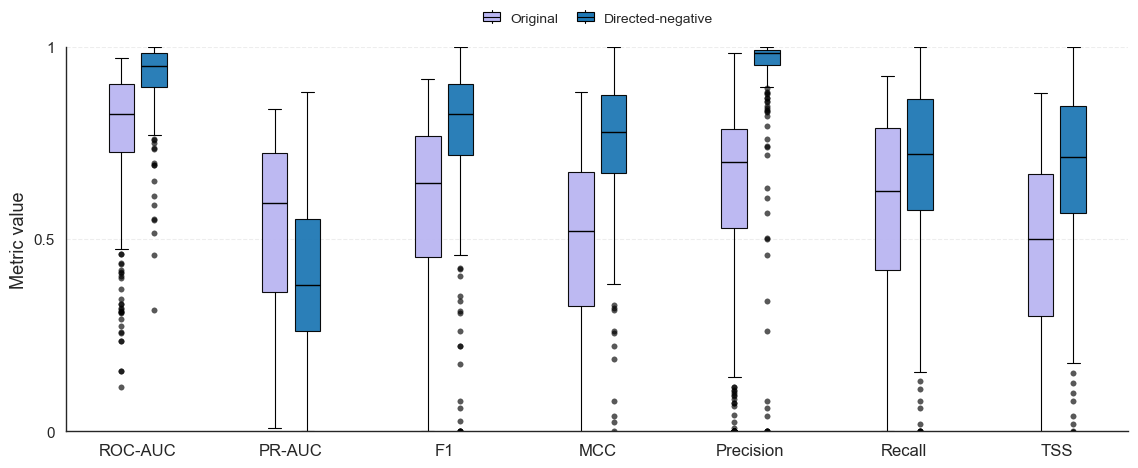

In [7]:
import os
import math
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.1)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
TRAIN_RATIO_TARGET = 90
THRESHOLD_TARGET = 0.5
NODES_THRESHOLD = 0

RESULTS_DIR_ORIGINAL = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

RESULTS_DIR_DIR_NEG = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_checkconn_strict_Apocrita"
    / "prediction_scores_logs"
)

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_checkconn_strict_Apocrita"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / (
    f"predictive_metrics_original_vs_dir_neg_"
    f"train{TRAIN_RATIO_TARGET}_threshold0p5_web_level.png"
)

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]

K_TARGET = None
K_COL = "K"
TRAIN_RATIO_COL = "TrainRatio"
THRESHOLD_COL = "Threshold"
THRESHOLD_MODE_COL = "ThresholdMode"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIR_NEG = "*_tax_mass_results_random_wlnm_dir_neg.csv"

SHOW_WEB_LEVEL_FLIERS = True

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

order = ["original", "dir_neg"]

label_map = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

palette = {
    "original": "#bab6f2",
    "dir_neg": "#1f78b4",
}

# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def read_csv_header(csv_path: Path) -> list[str]:
    with csv_path.open("r", errors="ignore") as f:
        return f.readline().strip().split(",")


# ============================================================
# Fast Polars loader
# ============================================================
def load_folder_polars(folder: Path, pattern: str, version: str) -> pl.DataFrame:
    csv_files = sorted(folder.glob(pattern))

    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    frames = []

    for csv_path in csv_files:
        header = read_csv_header(csv_path)

        needed_cols = [
            K_COL,
            TRAIN_RATIO_COL,
            THRESHOLD_COL,
            THRESHOLD_MODE_COL,
            *METRICS,
        ]

        present_cols = [c for c in needed_cols if c in header]

        if TRAIN_RATIO_COL not in present_cols:
            print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
            continue

        present_metrics = [m for m in METRICS if m in present_cols]
        if not present_metrics:
            print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
            continue

        schema_overrides = {
            TRAIN_RATIO_COL: pl.Float64,
            K_COL: pl.Float64,
            THRESHOLD_COL: pl.Float64,
            THRESHOLD_MODE_COL: pl.Utf8,
            **{m: pl.Float64 for m in present_metrics},
        }

        df_i = pl.read_csv(
            csv_path,
            columns=present_cols,
            schema_overrides={k: v for k, v in schema_overrides.items() if k in present_cols},
            null_values=["NaN", "nan", ""],
            ignore_errors=True,
        )

        foodweb = parse_foodweb_from_name(csv_path.name)

        df_i = df_i.with_columns([
            pl.lit(foodweb).alias("Foodweb"),
            pl.lit(normalize_fw_label(foodweb)).alias("FW_KEY"),
            pl.lit(version).alias("Version"),
            pl.lit(csv_path.name).alias("file"),
            pl.col(TRAIN_RATIO_COL).round(0).cast(pl.Int64),
        ])

        # Train ratio filter first.
        df_i = df_i.filter(pl.col(TRAIN_RATIO_COL) == TRAIN_RATIO_TARGET)

        if df_i.height == 0:
            continue

        # Threshold filter.
        # If threshold_sweep rows exist, keep only threshold_sweep at target threshold.
        # Otherwise keep fixed/default rows at target threshold.
        if THRESHOLD_COL in df_i.columns:
            df_i = df_i.with_columns(
                pl.col(THRESHOLD_COL).round(1).alias(THRESHOLD_COL)
            )

            if THRESHOLD_MODE_COL in df_i.columns:
                has_sweep = (
                    df_i
                    .select(
                        (pl.col(THRESHOLD_MODE_COL).str.to_lowercase() == "threshold_sweep")
                        .any()
                    )
                    .item()
                )

                if has_sweep:
                    df_i = df_i.filter(
                        (pl.col(THRESHOLD_MODE_COL).str.to_lowercase() == "threshold_sweep")
                        & (pl.col(THRESHOLD_COL) == THRESHOLD_TARGET)
                    )
                else:
                    df_i = df_i.filter(pl.col(THRESHOLD_COL) == THRESHOLD_TARGET)
            else:
                df_i = df_i.filter(pl.col(THRESHOLD_COL) == THRESHOLD_TARGET)

        if df_i.height == 0:
            continue

        if K_TARGET is not None and K_COL in df_i.columns:
            df_i = df_i.filter(pl.col(K_COL) == K_TARGET)
            if df_i.height == 0:
                continue

        # Add missing metric columns as null so concat is stable.
        missing_metrics = [m for m in METRICS if m not in df_i.columns]
        if missing_metrics:
            df_i = df_i.with_columns([
                pl.lit(None, dtype=pl.Float64).alias(m)
                for m in missing_metrics
            ])

        # Keep only compact columns.
        df_i = df_i.select([
            "Foodweb",
            "FW_KEY",
            "Version",
            "file",
            *METRICS,
        ])

        # Drop rows where all metrics are null.
        any_metric_valid = pl.any_horizontal([
            pl.col(m).is_not_null()
            for m in METRICS
        ])

        df_i = df_i.filter(any_metric_valid)

        if df_i.height > 0:
            frames.append(df_i)

    if not frames:
        return pl.DataFrame()

    return pl.concat(frames, how="vertical")


# ============================================================
# Load run-level CSVs with Polars
# ============================================================
run_pl = pl.concat(
    [
        load_folder_polars(
            RESULTS_DIR_ORIGINAL,
            GLOB_PATTERN_ORIGINAL,
            version="original",
        ),
        load_folder_polars(
            RESULTS_DIR_DIR_NEG,
            GLOB_PATTERN_DIR_NEG,
            version="dir_neg",
        ),
    ],
    how="vertical",
)

if run_pl.height == 0:
    raise RuntimeError("No valid rows after loading folders. Check paths or CSV columns.")

# ============================================================
# Apply node filter
# ============================================================
meta_pl = (
    pl.read_csv(FOODWEB_CSV)
    .rename({c: c.strip() for c in pl.read_csv(FOODWEB_CSV, n_rows=0).columns})
)

fw_col = next((c for c in meta_pl.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta_pl.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta_pl = (
    meta_pl
    .with_columns([
        pl.col(fw_col)
        .cast(pl.Utf8)
        .map_elements(normalize_fw_label, return_dtype=pl.Utf8)
        .alias("FW_KEY"),
        pl.col(nodes_col).cast(pl.Float64).alias("Nodes"),
    ])
    .filter(pl.col("Nodes") >= NODES_THRESHOLD)
    .select("FW_KEY")
    .unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {meta_pl.height}")
print(f"[INFO] Foodwebs in run-level results before node filter: {run_pl['FW_KEY'].n_unique()}")

run_pl = run_pl.join(meta_pl, on="FW_KEY", how="inner")

if run_pl.height == 0:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")
print(f"[INFO] Applied Threshold filter: Threshold == {THRESHOLD_TARGET}")
print(f"[INFO] Run-level rows after filtering: {run_pl.height:,}")

display(
    run_pl
    .group_by("Version")
    .agg(pl.len().alias("Rows"))
)

# ============================================================
# Web-level aggregation
# ============================================================
web_pl = (
    run_pl
    .group_by(["Foodweb", "FW_KEY", "Version"])
    .agg([
        *[pl.col(metric).mean().alias(metric) for metric in METRICS],
        pl.len().alias("ValidRuns"),
    ])
)

print(f"[INFO] Web-level rows after averaging runs: {web_pl.height:,}")

display(
    web_pl
    .group_by("Version")
    .agg([
        pl.col("Foodweb").n_unique().alias("FoodWebs"),
        pl.col("ValidRuns").min().alias("MinRuns"),
        pl.col("ValidRuns").median().alias("MedianRuns"),
        pl.col("ValidRuns").max().alias("MaxRuns"),
    ])
)

# Convert compact web-level data to pandas only for summary/plotting.
web_df = web_pl.to_pandas()

# ============================================================
# Summary table
# ============================================================
summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = web_df.loc[web_df["Version"] == version, metric_col].dropna()

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            "N food webs": int(vals.shape[0]),
            "Mean": vals.mean(),
            "Median": vals.median(),
            "SD": vals.std(ddof=1),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)
for col in ["Mean", "Median", "SD", "Variance"]:
    summary_table[col] = summary_table[col].round(4)

print("\n=== Web-level predictive metric summary ===")
display(summary_table)

# ============================================================
# Plot helpers
# ============================================================
class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

offsets = np.array([-0.16, 0.16])
box_width = 0.25

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            web_df.loc[web_df["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.65,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [label for _, label in plot_metrics],
    rotation=0,
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Metric value", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

In [30]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy import sparse
from IPython.display import display

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")
MAT_DIR = REPO_ROOT / "src/matlab/data/foodwebs_mat"

OLD_RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

NEW_RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_massdiag_trainmetrics_checkconnfalse_Apocrita"
)

TARGET_FOODWEBS = [
    "Skipwith Pond",
    "PC1P2",
]

ROLE_CODE = {
    "consumer": 1,
    "resource": 2,
    "consumer-resource": 3,
    "consumer resource": 3,
    "consumer_resource": 3,
}

ROLE_LABEL = {
    1: "Apex predator",
    2: "Basal resource",
    3: "Primary consumer",
    0: "Unknown",
}

# Same role-constrained candidate pairs used in sample_neg_dir_neg.m
ALLOWED_ROLE_PAIRS = {
    (1, 1),  # consumer -> consumer
    (2, 2),  # resource -> resource
    (1, 2),  # consumer -> resource
    (1, 3),  # consumer -> consumer-resource
    (3, 2),  # consumer-resource -> resource
}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


# -----------------------------
# Helpers
# -----------------------------
def clean_foodweb_name(name: str) -> str:
    return str(name).replace("_tax_mass", "").strip()


def find_mat_path(foodweb_name: str) -> Path:
    candidates = [
        MAT_DIR / f"{foodweb_name}.mat",
        MAT_DIR / f"{foodweb_name}_tax_mass.mat",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"No .mat file found for {foodweb_name}")


def matlab_string_array_to_list(x):
    arr = np.asarray(x).squeeze()

    if arr.ndim == 0:
        arr = np.array([arr.item()])

    values = []
    for item in arr.ravel():
        if isinstance(item, bytes):
            s = item.decode("utf-8", errors="ignore")
        elif isinstance(item, np.ndarray):
            item_arr = np.asarray(item).squeeze()
            if item_arr.dtype.kind in {"U", "S"}:
                s = "".join(item_arr.astype(str).ravel())
            else:
                s = str(item_arr.item()) if item_arr.ndim == 0 else str(item_arr)
        else:
            s = str(item)

        values.append(s.strip())

    return values


def numeric_vector(x, n=None):
    arr = np.asarray(x).squeeze()

    if arr.dtype == object:
        vals = []
        for item in arr.ravel():
            try:
                vals.append(float(np.asarray(item).squeeze()))
            except Exception:
                vals.append(np.nan)
        arr = np.array(vals, dtype=float)
    else:
        arr = arr.astype(float).ravel()

    if n is not None and arr.size < n:
        arr = np.concatenate([arr, np.full(n - arr.size, np.nan)])

    return arr[:n] if n is not None else arr


def load_foodweb(foodweb_name: str):
    mat_path = find_mat_path(foodweb_name)
    data = loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    net = data["net"]
    if sparse.issparse(net):
        net = net.toarray()
    net = np.asarray(net)
    net = (net != 0).astype(int)
    np.fill_diagonal(net, 0)

    n = net.shape[0]

    roles = matlab_string_array_to_list(data["role"])
    if len(roles) < n:
        roles = roles + ["unknown"] * (n - len(roles))
    roles = roles[:n]

    mass = numeric_vector(data.get("mass", np.full(n, np.nan)), n=n)

    return {
        "FoodWeb": foodweb_name,
        "mat_path": mat_path,
        "net": net,
        "roles": roles,
        "mass": mass,
        "n": n,
    }


def encode_role(role_value: str) -> int:
    return ROLE_CODE.get(str(role_value).strip().lower(), 0)


def compute_pool_diagnostics(net, role_codes, mass):
    n = net.shape[0]

    empirical_links = int(net.sum())
    total_possible_directed_pairs = n * (n - 1)
    full_nonlink_pool = total_possible_directed_pairs - empirical_links

    role_capacity_all_pairs = 0
    observed_links_in_role_capacity = 0

    category_counts = {
        "Role+Mass pool": 0,
        "Role+No mass pool": 0,
        "No role+Mass pool": 0,
        "No role+No mass pool": 0,
    }

    valid_mass = np.isfinite(mass) & (mass > 0)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            is_role = (int(role_codes[i]), int(role_codes[j])) in ALLOWED_ROLE_PAIRS

            is_mass = False
            if valid_mass[i] and valid_mass[j]:
                # Candidate i -> j means resource i to consumer j.
                # mass(j) / mass(i) < 1 means putative consumer is smaller than resource.
                is_mass = (mass[j] / mass[i]) < 1

            if is_role:
                role_capacity_all_pairs += 1
                if net[i, j] != 0:
                    observed_links_in_role_capacity += 1

            if net[i, j] != 0:
                continue

            if is_role and is_mass:
                category_counts["Role+Mass pool"] += 1
            elif is_role and not is_mass:
                category_counts["Role+No mass pool"] += 1
            elif (not is_role) and is_mass:
                category_counts["No role+Mass pool"] += 1
            else:
                category_counts["No role+No mass pool"] += 1

    role_pool_computed = (
        category_counts["Role+Mass pool"]
        + category_counts["Role+No mass pool"]
    )

    return {
        "Nodes": n,
        "Empirical links": empirical_links,
        "Total possible directed pairs": total_possible_directed_pairs,
        "Computed full non-link pool": full_nonlink_pool,
        "Role capacity before removing empirical links": role_capacity_all_pairs,
        "Observed links inside role capacity": observed_links_in_role_capacity,
        "Computed role-constrained pool": role_pool_computed,
        **category_counts,
    }


# -----------------------------
# Log parsers
# -----------------------------
negpool_pattern = re.compile(
    r"\[NegPool\].*?"
    r"mode=(?P<mode>\S+)"
    r"(?:\s+strategy=(?P<strategy>\S+))?.*?"
    r"role_pool=(?P<role_pool>\d+)\s+"
    r"full_pool=(?P<full_pool>\d+)\s+"
    r"need_total=(?P<need_total>\d+)"
    r"(?:\s+requested_need=(?P<requested_need>\d+))?"
    r"(?:\s+eligible_shortfall=(?P<eligible_shortfall>\d+))?"
    r"(?:\s+full_pool_shortfall=(?P<full_pool_shortfall>\d+))?"
    r".*?constrained_neg=(?P<constrained_neg>\d+)\s+"
    r"random_topup=(?P<random_topup>\d+)"
    r".*?k_train=(?P<k_train>\d+)\s+"
    r"k_test=(?P<k_test>\d+)"
)

mass_pattern = re.compile(
    r"\[NegMassPref\].*?"
    r"enabled=(?P<mass_enabled>\d+)\s+"
    r"active=(?P<mass_active>\d+)"
    r"(?:\s+priority_sampling=(?P<priority_sampling>\d+))?\s+"
    r"threshold=(?P<mass_threshold>[\d.eE+-]+)\s+"
    r"valid_mass_nodes=(?P<valid_mass_nodes>\d+)/(?P<total_mass_nodes>\d+).*?"
    r"selected_mass_pref=(?P<selected_mass_pref>\d+)\s+"
    r"role_mass=(?P<role_mass>\d+)\s+"
    r"role_other=(?P<role_other>\d+)\s+"
    r"nonrole_mass=(?P<nonrole_mass>\d+)\s+"
    r"nonrole_other=(?P<nonrole_other>\d+)"
)


def parse_result_logs(result_dir: Path, label: str, sampling_logic: str):
    log_dir = result_dir / "terminal_logs"
    if not log_dir.exists():
        raise FileNotFoundError(f"Missing terminal_logs directory: {log_dir}")

    topup_rows = []
    mass_rows = []

    for log_file in sorted(log_dir.glob("*_wlnm_dir_neg_terminal_log.txt")):
        foodweb = clean_foodweb_name(
            log_file.name.replace("_wlnm_dir_neg_terminal_log.txt", "")
        )

        if foodweb not in TARGET_FOODWEBS:
            continue

        neg_matches = []
        mass_matches = []

        for line in log_file.read_text(errors="ignore").splitlines():
            neg_match = negpool_pattern.search(line)
            if neg_match:
                row = neg_match.groupdict()
                for key, value in list(row.items()):
                    if value is None:
                        continue
                    if key not in {"mode", "strategy"}:
                        row[key] = int(value)
                neg_matches.append(row)

            mass_match = mass_pattern.search(line)
            if mass_match:
                row = mass_match.groupdict()
                for key, value in list(row.items()):
                    if value is None:
                        continue
                    if key == "mass_threshold":
                        row[key] = float(value)
                    else:
                        row[key] = int(value)
                mass_matches.append(row)

        if not neg_matches:
            continue

        neg_df = pd.DataFrame(neg_matches).drop_duplicates().reset_index(drop=True)
        neg = neg_df.iloc[0].to_dict()

        role_shortfall = max(0, int(neg["need_total"]) - int(neg["role_pool"]))
        full_pool_shortfall = neg.get("full_pool_shortfall")
        if pd.isna(full_pool_shortfall) or full_pool_shortfall is None:
            full_pool_shortfall = max(0, int(neg["need_total"]) - int(neg["full_pool"]))

        eligible_shortfall = neg.get("eligible_shortfall")
        if pd.isna(eligible_shortfall) or eligible_shortfall is None:
            eligible_shortfall = role_shortfall

        if int(neg["full_pool"]) < int(neg["need_total"]):
            scenario = "Insufficient full non-link pool"
        elif int(neg["role_pool"]) < int(neg["need_total"]):
            scenario = "Needs controlled non-role top-up"
        else:
            scenario = "Role-constrained pool sufficient"

        topup_rows.append({
            "FoodWeb": foodweb,
            "Result set": label,
            "Sampling logic": sampling_logic,
            "Mode": neg.get("mode", ""),
            "Strategy": neg.get("strategy", "priority_based_or_legacy"),
            "Required negative links": int(neg["need_total"]),
            "Role-constrained pool": int(neg["role_pool"]),
            "Full non-link pool": int(neg["full_pool"]),
            "Role shortfall": role_shortfall,
            "Eligible shortfall": int(eligible_shortfall),
            "Full-pool shortfall": int(full_pool_shortfall),
            "Constrained negatives selected": int(neg["constrained_neg"]),
            "Non-role top-up selected": int(neg["random_topup"]),
            "Train positives": int(neg["k_train"]),
            "Test positives": int(neg["k_test"]),
            "Unique NegPool states": len(neg_df),
            "Scenario": scenario,
        })

        if mass_matches:
            mass_df = pd.DataFrame(mass_matches)
            numeric_cols = [
                "selected_mass_pref",
                "role_mass",
                "role_other",
                "nonrole_mass",
                "nonrole_other",
            ]

            agg = {
                f"Median {col}": float(mass_df[col].median())
                for col in numeric_cols
                if col in mass_df.columns
            }

            priority_sampling = (
                mass_df["priority_sampling"].dropna().iloc[0]
                if "priority_sampling" in mass_df.columns and mass_df["priority_sampling"].notna().any()
                else "legacy"
            )

            mass_rows.append({
                "FoodWeb": foodweb,
                "Result set": label,
                "Sampling logic": sampling_logic,
                "Priority sampling": priority_sampling,
                "Mass diagnostic enabled": int(mass_df["mass_enabled"].dropna().iloc[0]),
                "Mass diagnostic active": int(mass_df["mass_active"].dropna().iloc[0]),
                "Valid mass nodes": int(mass_df["valid_mass_nodes"].dropna().iloc[0]),
                "Total nodes in mass log": int(mass_df["total_mass_nodes"].dropna().iloc[0]),
                "Unique mass-composition states": len(mass_df.drop_duplicates()),
                **agg,
            })

    return pd.DataFrame(topup_rows), pd.DataFrame(mass_rows)


# -----------------------------
# Build tables
# -----------------------------
old_topup_df, old_mass_df = parse_result_logs(
    OLD_RESULT_DIR,
    label="Previous mass-priority run",
    sampling_logic="priority-based mass preference",
)

new_topup_df, new_mass_df = parse_result_logs(
    NEW_RESULT_DIR,
    label="New random eligible-pool run",
    sampling_logic="random_eligible_pool",
)

topup_comparison_df = pd.concat([old_topup_df, new_topup_df], ignore_index=True)
mass_composition_df = pd.concat([old_mass_df, new_mass_df], ignore_index=True)

role_rows = []
cause_rows = []

for foodweb in TARGET_FOODWEBS:
    fw = load_foodweb(foodweb)
    net = fw["net"]
    role_codes = np.array([encode_role(r) for r in fw["roles"]], dtype=int)
    mass = fw["mass"]

    role_counts = pd.Series(role_codes).map(ROLE_LABEL).value_counts().to_dict()
    pool_diag = compute_pool_diagnostics(net, role_codes, mass)

    new_row = new_topup_df[new_topup_df["FoodWeb"].eq(foodweb)].iloc[0].to_dict()

    role_rows.append({
        "FoodWeb": foodweb,
        "Basal resources": int(role_counts.get("Basal resource", 0)),
        "Primary consumers": int(role_counts.get("Primary consumer", 0)),
        "Apex predators": int(role_counts.get("Apex predator", 0)),
        "Unknown roles": int(role_counts.get("Unknown", 0)),
        **pool_diag,
        "Log role-constrained pool": int(new_row["Role-constrained pool"]),
        "Log full non-link pool": int(new_row["Full non-link pool"]),
        "Role-pool matches log": int(pool_diag["Computed role-constrained pool"]) == int(new_row["Role-constrained pool"]),
        "Full-pool matches log": int(pool_diag["Computed full non-link pool"]) == int(new_row["Full non-link pool"]),
    })

    role_pool_insufficient = int(new_row["Role-constrained pool"]) < int(new_row["Required negative links"])
    full_pool_sufficient = int(new_row["Full non-link pool"]) >= int(new_row["Required negative links"])
    observed_role_links = int(pool_diag["Observed links inside role capacity"])

    if role_pool_insufficient and full_pool_sufficient:
        primary_cause = "Insufficient role-constrained non-links; full non-link pool is sufficient"
    elif role_pool_insufficient and not full_pool_sufficient:
        primary_cause = "Insufficient full non-link pool"
    else:
        primary_cause = "Role-constrained pool is sufficient"

    if observed_role_links == 0:
        observed_link_effect = "Observed links do not reduce the role-constrained pool"
    else:
        observed_link_effect = "Observed links remove some otherwise role-valid candidates"

    cause_rows.append({
        "FoodWeb": foodweb,
        "Required negative links": int(new_row["Required negative links"]),
        "Role-constrained pool": int(new_row["Role-constrained pool"]),
        "Full non-link pool": int(new_row["Full non-link pool"]),
        "Eligible shortfall": int(new_row["Eligible shortfall"]),
        "Full-pool shortfall": int(new_row["Full-pool shortfall"]),
        "Role pool insufficient": role_pool_insufficient,
        "Full pool sufficient": full_pool_sufficient,
        "Connectivity contributes": False,
        "Why connectivity contributes": "No, this run uses checkConnectivity=false and adaptiveConnectivity=false",
        "Observed links inside role capacity": observed_role_links,
        "Observed-link effect": observed_link_effect,
        "Basal resources": int(role_counts.get("Basal resource", 0)),
        "Apex predators": int(role_counts.get("Apex predator", 0)),
        "Primary cause": primary_cause,
    })

role_pool_diagnostics_df = pd.DataFrame(role_rows)
cause_summary_df = pd.DataFrame(cause_rows)


# -----------------------------
# Display
# -----------------------------
print("Table 1. Previous vs new top-up requirements")
display(
    topup_comparison_df.sort_values(["FoodWeb", "Result set"]).reset_index(drop=True)
)

print("Table 2. Body-mass composition: old priority vs new diagnostic descriptor")
display(
    mass_composition_df.sort_values(["FoodWeb", "Result set"]).reset_index(drop=True)
)

print("Table 3. Role counts and candidate-pool diagnostics")
display(
    role_pool_diagnostics_df.sort_values("FoodWeb").reset_index(drop=True)
)

print("Table 4. Causal summary for top-up requirement")
display(
    cause_summary_df.sort_values("FoodWeb").reset_index(drop=True)
)

Table 1. Previous vs new top-up requirements


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_27808/791681535.py:125: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
        That means the default return type will be a sparse array.
        Unless you use * instead of @, ** for matrix power, or you depend
        on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
        See the spmatrix to sparray migration guide for details.
        https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
        
  data = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_27808/791681535.py:125: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
        That means the default return type will be a sparse array.
        Unless you use * instead of @, ** for matrix power, or you depend
        on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
        

,FoodWeb,Result set,Sampling logic,Mode,Strategy,Required negative links,Role-constrained pool,Full non-link pool,Role shortfall,Eligible shortfall,Full-pool shortfall,Constrained negatives selected,Non-role top-up selected,Train positives,Test positives,Unique NegPool states,Scenario
0,PC1P2,New random eligible-pool run,random_eligible_pool,hybrid,random_eligible_pool,212,120,314,92,92,0,120,92,20,192,9,Needs controlled non-role top-up
1,PC1P2,Previous mass-priority run,priority-based mass preference,hybrid,None,212,120,314,92,92,0,120,92,20,192,9,Needs controlled non-role top-up
2,Skipwith Pond,New random eligible-pool run,random_eligible_pool,hybrid,random_eligible_pool,708,65,768,643,643,0,65,643,70,638,9,Needs controlled non-role top-up
3,Skipwith Pond,Previous mass-priority run,priority-based mass preference,hybrid,None,708,65,768,643,643,0,65,643,70,638,9,Needs controlled non-role top-up


Table 2. Body-mass composition: old priority vs new diagnostic descriptor


,FoodWeb,Result set,Sampling logic,Priority sampling,Mass diagnostic enabled,Mass diagnostic active,Valid mass nodes,Total nodes in mass log,Unique mass-composition states,Median selected_mass_pref,Median role_mass,Median role_other,Median nonrole_mass,Median nonrole_other
0,PC1P2,New random eligible-pool run,random_eligible_pool,0,1,1,21,21,21,136.0,95.0,25.0,41.0,51.0
1,PC1P2,Previous mass-priority run,priority-based mass preference,legacy,1,1,21,21,1,182.0,95.0,25.0,87.0,5.0
2,Skipwith Pond,New random eligible-pool run,random_eligible_pool,0,1,1,33,34,21,415.0,9.0,56.0,406.0,237.0
3,Skipwith Pond,Previous mass-priority run,priority-based mass preference,legacy,1,1,33,34,1,453.0,9.0,56.0,444.0,199.0


Table 3. Role counts and candidate-pool diagnostics


,FoodWeb,Basal resources,Primary consumers,Apex predators,Unknown roles,Nodes,Empirical links,Total possible directed pairs,Computed full non-link pool,Role capacity before removing empirical links,Observed links inside role capacity,Computed role-constrained pool,Role+Mass pool,Role+No mass pool,No role+Mass pool,No role+No mass pool,Log role-constrained pool,Log full non-link pool,Role-pool matches log,Full-pool matches log
0,PC1P2,6,15,0,0,21,106,420,314,120,0,120,95,25,87,107,120,314,True,True
1,Skipwith Pond,1,32,1,0,34,354,1122,768,65,0,65,9,56,444,259,65,768,True,True


Table 4. Causal summary for top-up requirement


,FoodWeb,Required negative links,Role-constrained pool,Full non-link pool,Eligible shortfall,Full-pool shortfall,Role pool insufficient,Full pool sufficient,Connectivity contributes,Why connectivity contributes,Observed links inside role capacity,Observed-link effect,Basal resources,Apex predators,Primary cause
0,PC1P2,212,120,314,92,0,True,True,False,"No, this run uses checkConnectivity=false and ...",0,Observed links do not reduce the role-constrai...,6,0,Insufficient role-constrained non-links; full ...
1,Skipwith Pond,708,65,768,643,0,True,True,False,"No, this run uses checkConnectivity=false and ...",0,Observed links do not reduce the role-constrai...,1,1,Insufficient role-constrained non-links; full ...


## Critical:

1.- Fix model. next time, come with a defined configuration and combination that is the best and we will use

    Analyse the check_connectivity and adaptive_connectivity flags in DivideNet_dir_neg:

    identify where they are used,
    document how they affect the negative-sampling and train/test split logic,
    determine whether they alter graph connectivity, candidate-pair availability, or model input consistency.

    If necessary, run controlled tests with check_connectivity and adaptive_connectivity activated and deactivated to evaluate their effect on:

    number of retained food webs,
    number of valid runs,
    positive/negative sample availability,
    ROC-AUC,
    PR-AUC,
    threshold-dependent metrics.

2.- adjust the negative sampling logic to avoid bias and first create a pool and randomly choose these links. Do not use priorities in the negative sampling.

3.- plot the 2 foodwebs that require random top-up and find how many top predators and basal species.

    - calculate how many nodes we have for each rol class
    - understand from the data, what is the distribution of the body mass ratio
    - are the consumers bigger? If consumer bigger: what is the ratio? Is it 1 or larger than 1?
    - get proposals to relax the ecological constraints
    - Pedir a Lalchan que me explique su grafico de distribucion del ratio de masas por ecosistema (density of links vs log10 consumer/resoruce mass)
    - first apply sweep threshold 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1 to check how this affect the performance (ask Lachlan) (consumer to reource ratio below 1)
    - based on the results. implement a predation filter for each ecosystem or foodweb, e.g., parasites, bacteria

    - summary of the links we got correct: TP and TN, to identify which type of interation they are (to point is as future work)
    - summary of the links we got wrong: FP and FN, to identify which type of interation they are (to point is as future work)

---

- apply tukey iqr fencees to all the plots, not only for figure 5, (apply it to figure 3)
- define a minimum amount of valid runs to make it equiuvalent the calculation of mean per foodweb (e.g., train ratio=60, mean trophic height has MinRetainedRuns=25)
- take the 25 valid/best runs for all the plots.


- 2 version of figure 5, 
  - main: only 2 boxplots
  - SI: with 3 boxplots

- put the figures in a new version of the document or in a presentation

---

- Learn by heart the WL graph labeling algorithm and understand how does teh colors/labels are asigned and how do we break the ties.
- Also review the Palette-WL algorithm and brind an examplo step by step.
- Generate a new version of figure 1 that also includes the negative sampling.
- Are we input 1 big vector into the FFNN? Or are we input multiple vectors to the FFNN per each enclosed subgraph?